# Qwen3-8B TurboQuant KV-Cache — Performance & Quality Analysis

**Model:** `Qwen/Qwen3-8B` on GKE (NVIDIA GPU)  
**Engine:** vLLM · tensor-parallel 1  
**Load generator:** Locust (streaming SSE)

## Test runs

| Run | Run ID | Experiments | Concurrency |
|-----|--------|-------------|-------------|
| **Run 1** | `run_20260511_234500` | `qwen3_kv_fp8_baseline`, `qwen3_kv_turboquant_4bit_nc`, `qwen3_kv_turboquant_k8v4` | 32 / 64 / 128 |
| **Run 2** | `run_20260512_090311` | `qwen3_kv_turboquant_3bit_nc`, `qwen3_kv_turboquant_k3v4_nc` | 32 / 64 / 128 (3bit), 64 / 128 (k3v4) |

All TurboQuant variants are compared against the **FP8 KV-cache baseline** (`--kv-cache-dtype fp8`).

| Experiment | KV-cache dtype | Notes |
|---|---|---|
| `qwen3_kv_fp8_baseline` | `fp8` | Baseline (8-bit float) |
| `qwen3_kv_turboquant_k8v4` | `turboquant_k8v4` | FP8 keys + 4-bit values, no norm correction |
| `qwen3_kv_turboquant_4bit_nc` | `turboquant_4bit_nc` | 4-bit keys + 4-bit values + norm correction |
| `qwen3_kv_turboquant_k3v4_nc` | `turboquant_k3v4_nc` | 3-bit keys + 4-bit values + norm correction |
| `qwen3_kv_turboquant_3bit_nc` | `turboquant_3bit_nc` | 3-bit keys + 3-bit values + norm correction (max compression) |

## Quality evaluation (`lm-evaluation-harness`)
Two reasoning-mode tasks executed against each KV-cache variant:
- **`arc_challenge`** — 5-shot, 1000 samples — `acc` / `acc_norm`
- **`gsm8k`** — 5-shot, 1000 samples — `exact_match` (strict-match / flexible-extract)

Grafana snapshots:
- Run 1: https://snapshots.raintank.io/dashboard/snapshot/50Lems4r8TZGNzprmjXEGQHuT0rkvsPi
- Run 2: https://snapshots.raintank.io/dashboard/snapshot/dJqN5aINpnl9TmdGr8yUvM4QY0DgpkYN

In [1]:
import glob, json, os, re, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 200,
    'font.size': 10,
    'axes.titlesize': 12,
    'figure.titlesize': 14,
})

# ─── Configuration ──────────────────────────────────────────────────────────
RESULTS_ROOT = Path('results')
EVAL_ROOT    = Path('..') / 'evaluation' / 'results' / 'qwen-3'

RUN1_ID = 'run_20260511_234500'   # fp8_baseline, 4bit_nc, k8v4
RUN2_ID = 'run_20260512_090311'   # 3bit_nc, k3v4_nc

BASELINE_EXP = 'qwen3_kv_fp8_baseline'

# Order experiments from least to most aggressive KV compression
EXP_ORDER = [
    'qwen3_kv_fp8_baseline',
    'qwen3_kv_turboquant_k8v4',
    'qwen3_kv_turboquant_4bit_nc',
    'qwen3_kv_turboquant_k3v4_nc',
    'qwen3_kv_turboquant_3bit_nc',
]
EXP_SHORT = {
    'qwen3_kv_fp8_baseline':       'fp8 (baseline)',
    'qwen3_kv_turboquant_k8v4':    'tq k8v4',
    'qwen3_kv_turboquant_4bit_nc': 'tq 4bit_nc',
    'qwen3_kv_turboquant_k3v4_nc': 'tq k3v4_nc',
    'qwen3_kv_turboquant_3bit_nc': 'tq 3bit_nc',
}

# Mapping: benchmark experiment name -> evaluation results subfolder
EXP_TO_EVAL_DIR = {
    'qwen3_kv_fp8_baseline':       'fp8-model&fp8-kv-cache',
    'qwen3_kv_turboquant_k8v4':    'fp8-model&turboquant_k8v4-kv-cache',
    'qwen3_kv_turboquant_4bit_nc': 'fp8-model&turboquant_4bit_nc-kv-cache',
    'qwen3_kv_turboquant_k3v4_nc': 'fp8-model&turboquant_k3v4_nc-kv-cache',
    'qwen3_kv_turboquant_3bit_nc': 'fp8-model&turboquant_3bit_nc-kv-cache',
}

GPU_HOURLY_COST_USD = 1.58

## 1. Load benchmark data (Locust + Prometheus)

In [2]:
def load_run_locust(run_dir: Path, run_label: str) -> pd.DataFrame:
    frames = []
    for csv_path in sorted(run_dir.rglob('*custom_metrics*.csv')):
        stem = csv_path.stem
        exp  = csv_path.parent.name
        m = re.search(r'__u(\d+)', stem)
        users = int(m.group(1)) if m else 0
        df = pd.read_csv(csv_path)
        df['experiment'], df['users'], df['run'] = exp, users, run_label
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_run_prometheus(run_dir: Path, run_label: str) -> pd.DataFrame:
    frames = []
    for csv_path in sorted(run_dir.rglob('*prometheus_metrics*.csv')):
        stem = csv_path.stem
        exp  = csv_path.parent.name
        m = re.search(r'__u(\d+)', stem)
        users = int(m.group(1)) if m else 0
        try:
            df = pd.read_csv(csv_path)
            df['experiment'], df['users'], df['run'] = exp, users, run_label
            frames.append(df)
        except Exception as e:
            print(f'Warning: {csv_path.name}: {e}')
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

run1_dir = RESULTS_ROOT / RUN1_ID
run2_dir = RESULTS_ROOT / RUN2_ID

df_run1 = load_run_locust(run1_dir, 'run1')
df_run2 = load_run_locust(run2_dir, 'run2')
df_all  = pd.concat([df_run1, df_run2], ignore_index=True)
df_ok   = df_all[df_all['success'] == True].copy()

prom_run1 = load_run_prometheus(run1_dir, 'run1')
prom_run2 = load_run_prometheus(run2_dir, 'run2')
prom_all  = pd.concat([prom_run1, prom_run2], ignore_index=True)

# Drop experiments that have no data (e.g. empty k3v4_nc folder in Run 1)
df_ok = df_ok[df_ok['experiment'].isin(EXP_ORDER)].copy()

print(f'Run 1  ({RUN1_ID}): {len(df_run1):>6,} rows | {df_run1["experiment"].nunique()} experiments')
print(f'Run 2  ({RUN2_ID}): {len(df_run2):>6,} rows | {df_run2["experiment"].nunique()} experiments')
print('────────────────────────────────────────────')
print(f'Total loaded   : {len(df_all):>6,}')
print(f'Successful     : {len(df_ok):>6,} ({100*len(df_ok)/max(len(df_all),1):.1f}%)')
print(f'Failed         : {len(df_all)-len(df_ok):>6,}')
print(f'\nPrometheus metrics: {len(prom_all):,} rows')

df_ok.head(3)

Run 1  (run_20260511_234500):    794 rows | 3 experiments
Run 2  (run_20260512_090311):    412 rows | 2 experiments
────────────────────────────────────────────
Total loaded   :  1,206
Successful     :  1,093 (90.6%)
Failed         :    113

Prometheus metrics: 95,327 rows


,timestamp,category,approx_chars,output_tokens,ttft_ms,tpot_ms,e2e_ms,itl_p50_ms,itl_p99_ms,finish_reason,success,error_type,experiment,users,run
0,50854.717311,long,9488,245,1058.022370,121.603412,30729.254965,80.300512,463.963409,stop,True,NaN,qwen3_kv_fp8_baseline,128,run1
1,50859.405472,long,2232,341,302.495692,118.659288,40646.653654,91.968677,467.165764,stop,True,NaN,qwen3_kv_fp8_baseline,128,run1
2,50875.373495,medium,478,428,298.814192,112.773462,48453.082585,96.600351,471.012514,stop,True,NaN,qwen3_kv_fp8_baseline,128,run1


In [3]:
# ─── Experiment matrix ─────────────────────────────────────────────────────
matrix = (
    df_ok.groupby(['experiment', 'users'])
    .agg(n=('ttft_ms', 'count'))
    .reset_index()
    .pivot_table(index='experiment', columns='users', values='n', fill_value=0)
    .astype(int)
)
matrix.columns = [f'u{c}' for c in matrix.columns]
matrix = matrix.reindex([e for e in EXP_ORDER if e in matrix.index])

# Pull short description from each experiment's config.json
desc_map = {}
for cfg in RESULTS_ROOT.rglob('config.json'):
    c = json.loads(cfg.read_text())
    desc_map[c['name']] = c.get('description', '')
matrix['description'] = [desc_map.get(e, '') for e in matrix.index]

print('Experiment matrix (successful request counts per concurrency):')
display(matrix)

Experiment matrix (successful request counts per concurrency):


,u32,u64,u128,description
experiment,,,,
qwen3_kv_fp8_baseline,76,125,162,FP8 KV cache baseline for Qwen3-8B — reference...
qwen3_kv_turboquant_k8v4,53,72,40,TurboQuant with FP8 keys + 4-bit values on Qwe...
qwen3_kv_turboquant_4bit_nc,51,80,86,TurboQuant with 4-bit MSE keys + 4-bit values ...
qwen3_kv_turboquant_k3v4_nc,0,67,76,TurboQuant with 3-bit MSE keys + 4-bit values ...
qwen3_kv_turboquant_3bit_nc,53,83,69,TurboQuant with 3-bit MSE keys + 3-bit values ...


## 2. Client-side latency summary

In [4]:
def pct(s, p):
    return s.quantile(p / 100)

def build_summary(df, by_category=False):
    group_cols = ['experiment', 'users']
    if by_category and 'category' in df.columns:
        group_cols.append('category')
    return (
        df.groupby(group_cols)
        .agg(
            n             = ('ttft_ms', 'count'),
            ttft_mean     = ('ttft_ms', 'mean'),
            ttft_p50      = ('ttft_ms', lambda s: pct(s, 50)),
            ttft_p95      = ('ttft_ms', lambda s: pct(s, 95)),
            ttft_p99      = ('ttft_ms', lambda s: pct(s, 99)),
            tpot_mean     = ('tpot_ms', 'mean'),
            tpot_p50      = ('tpot_ms', lambda s: pct(s, 50)),
            tpot_p99      = ('tpot_ms', lambda s: pct(s, 99)),
            e2e_mean      = ('e2e_ms', 'mean'),
            e2e_p50       = ('e2e_ms', lambda s: pct(s, 50)),
            e2e_p99       = ('e2e_ms', lambda s: pct(s, 99)),
            itl_p50_mean  = ('itl_p50_ms', 'mean'),
            itl_p99_mean  = ('itl_p99_ms', 'mean'),
            output_tokens = ('output_tokens', 'sum'),
        )
        .reset_index()
    )

summary_agg = build_summary(df_ok)
summary_cat = build_summary(df_ok, by_category=True)

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.1f}'.format)

print('Aggregated latency summary (across all prompt categories):')
display(summary_agg.set_index(['experiment', 'users']).reindex(
    [(e, u) for e in EXP_ORDER for u in sorted(summary_agg['users'].unique())]
).dropna(how='all'))

Aggregated latency summary (across all prompt categories):


n  ttft_mean  ttft_p50  ttft_p95  \
experiment                  users                                        
qwen3_kv_fp8_baseline       32     76.0     1033.3     445.6    5901.5   
                            64    125.0      876.0     499.1    1639.2   
                            128   162.0    68028.8    1019.9  225835.1   
qwen3_kv_turboquant_k8v4    32     53.0     1491.7     542.3    8452.3   
                            64     72.0    27441.6     554.4  169227.9   
                            128    40.0    63276.4     929.9  272999.3   
qwen3_kv_turboquant_4bit_nc 32     51.0     1683.3     649.3    9463.5   
                            64     80.0    15050.3     610.7  110159.8   
                            128    86.0    27968.1     810.5  249682.6   
qwen3_kv_turboquant_k3v4_nc 64     67.0     8913.8     770.6   58352.1   
                            128    76.0     7916.1     738.2    1742.2   
qwen3_kv_turboquant_3bit_nc 32     53.0     1387.1     659.8    7139.0   
                            64     83.0      684.4     666.0    1068.3   
                            128    69.0     3818.5     826.6    1997.0   

                                   ttft_p99  tpot_mean  tpot_p50  tpot_p99  \
experiment                  users                                            
qwen3_kv_fp8_baseline       32      10763.9       63.6      64.1      79.9   
                            64      11503.9       87.5      89.2     100.8   
                            128    239384.9      118.7     107.3     266.7   
qwen3_kv_turboquant_k8v4    32      12253.9       94.3      95.9     107.6   
                            64     192319.5      152.7     131.3     403.8   
                            128    293132.9      175.1     137.7     514.8   
qwen3_kv_turboquant_4bit_nc 32      13111.1       99.7     101.4     114.5   
                            64     136858.4      151.4     150.1     237.7   
                            128    299838.4      224.4     170.1    1106.6   
qwen3_kv_turboquant_k3v4_nc 64      75511.0      177.4     175.8     236.9   
                            128    264405.4      218.7     201.6     590.7   
qwen3_kv_turboquant_3bit_nc 32      11082.5      112.3     112.1     131.2   
                            64       1457.5      171.7     174.3     198.2   
                            128     64519.4      250.4     220.4     668.4   

                                   e2e_mean  e2e_p50  e2e_p99  itl_p50_mean  \
experiment                  users                                             
qwen3_kv_fp8_baseline       32     121423.7 101658.0 424944.4          60.0   
                            64     145536.4 137107.5 355666.6          81.1   
                            128    243603.3 244929.4 467792.5          91.6   
qwen3_kv_turboquant_k8v4    32     173423.8 163928.2 379325.3          91.1   
                            64     257614.5 254701.3 489433.7         120.4   
                            128    256157.5 246515.4 488823.5         126.8   
qwen3_kv_turboquant_4bit_nc 32     174252.3 160623.8 351366.5          97.6   
                            64     254342.6 255297.1 492628.0         144.3   
                            128    299861.8 304974.2 504386.8         157.4   
qwen3_kv_turboquant_k3v4_nc 64     240840.6 229213.2 489829.1         172.1   
                            128    276271.3 277533.6 514387.2         190.0   
qwen3_kv_turboquant_3bit_nc 32     184727.8 168016.2 407156.6         110.9   
                            64     234433.7 235148.4 466824.3         170.8   
                            128    309399.3 310312.9 518748.5         206.5   

                                   itl_p99_mean  output_tokens  
experiment                  users                               
qwen3_kv_fp8_baseline       32            160.8       147636.0  
                            64            371.3       208868.0  
                            128           472.6       243524.0  
qwen3_kv_turbo

## 3. Latency distributions (TTFT / TPOT / E2E)

/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_35482/2177155933.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EXP_SHORT.get(e, e) for e in order], rotation=25, ha='right')
/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_35482/2177155933.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EXP_SHORT.get(e, e) for e in order], rotation=25, ha='right')
/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_35482/2177155933.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EXP_SHORT.get(e, e) for e in order], rotation=25, ha='right')


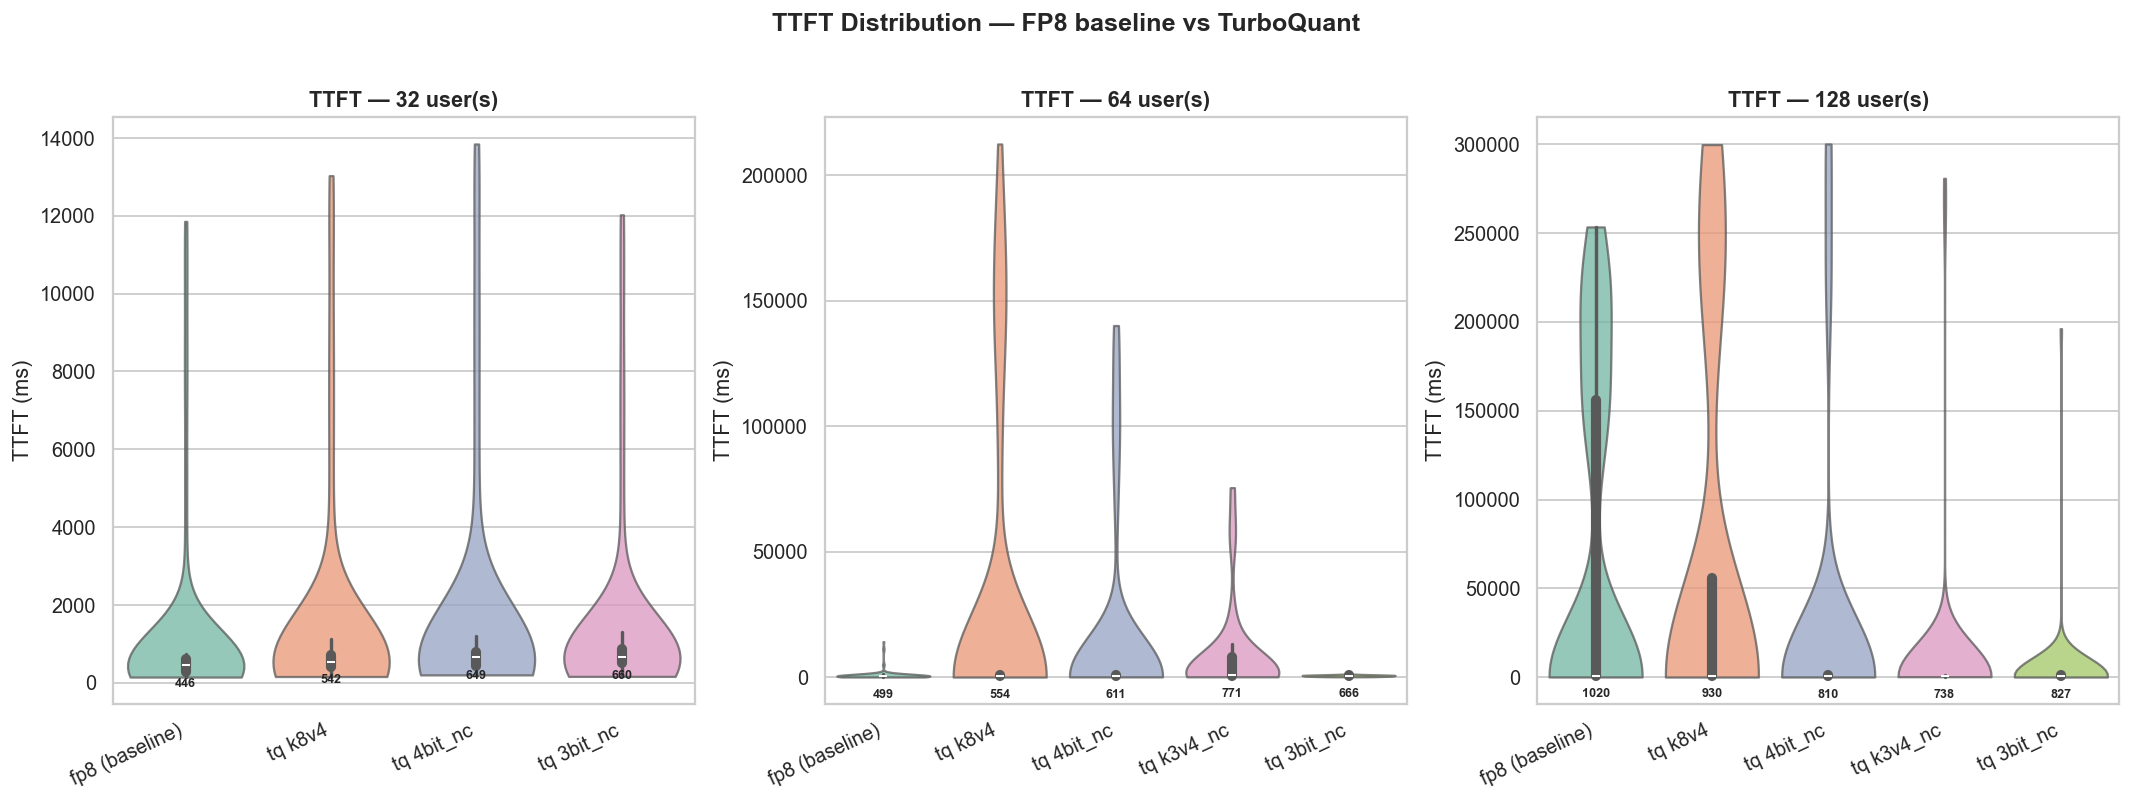

In [5]:
def _exp_order_in(df):
    return [e for e in EXP_ORDER if e in df['experiment'].unique()]

def violin_by_users(df, metric, title, ylabel, palette='Set2', fmt='{:.0f}'):
    user_levels = sorted(df['users'].unique())
    n_u = len(user_levels)
    fig, axes = plt.subplots(1, n_u, figsize=(5.5 * n_u, 6), sharey=False)
    if n_u == 1:
        axes = [axes]
    for ax, u in zip(axes, user_levels):
        sub = df[df['users'] == u]
        order = [e for e in _exp_order_in(sub)]
        sns.violinplot(data=sub, x='experiment', y=metric, order=order,
                       inner='box', cut=0, ax=ax, palette=palette, alpha=0.75)
        ax.set_title(f'{title} — {u} user(s)', fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(ylabel)
        ax.set_xticklabels([EXP_SHORT.get(e, e) for e in order], rotation=25, ha='right')
        for i, exp in enumerate(order):
            med = sub[sub['experiment'] == exp][metric].median()
            if pd.notna(med):
                ax.annotate(fmt.format(med), (i, med), textcoords='offset points',
                            xytext=(0, -12), ha='center', fontsize=7, fontweight='bold')
    plt.suptitle(f'{title} Distribution — FP8 baseline vs TurboQuant', fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig

fig = violin_by_users(df_ok, 'ttft_ms', 'TTFT', 'TTFT (ms)', palette='Set2', fmt='{:.0f}')
plt.savefig(RESULTS_ROOT / 'turboquant_ttft_violin.png', bbox_inches='tight')
plt.show()

/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_35482/2177155933.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EXP_SHORT.get(e, e) for e in order], rotation=25, ha='right')
/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_35482/2177155933.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EXP_SHORT.get(e, e) for e in order], rotation=25, ha='right')
/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_35482/2177155933.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EXP_SHORT.get(e, e) for e in order], rotation=25, ha='right')


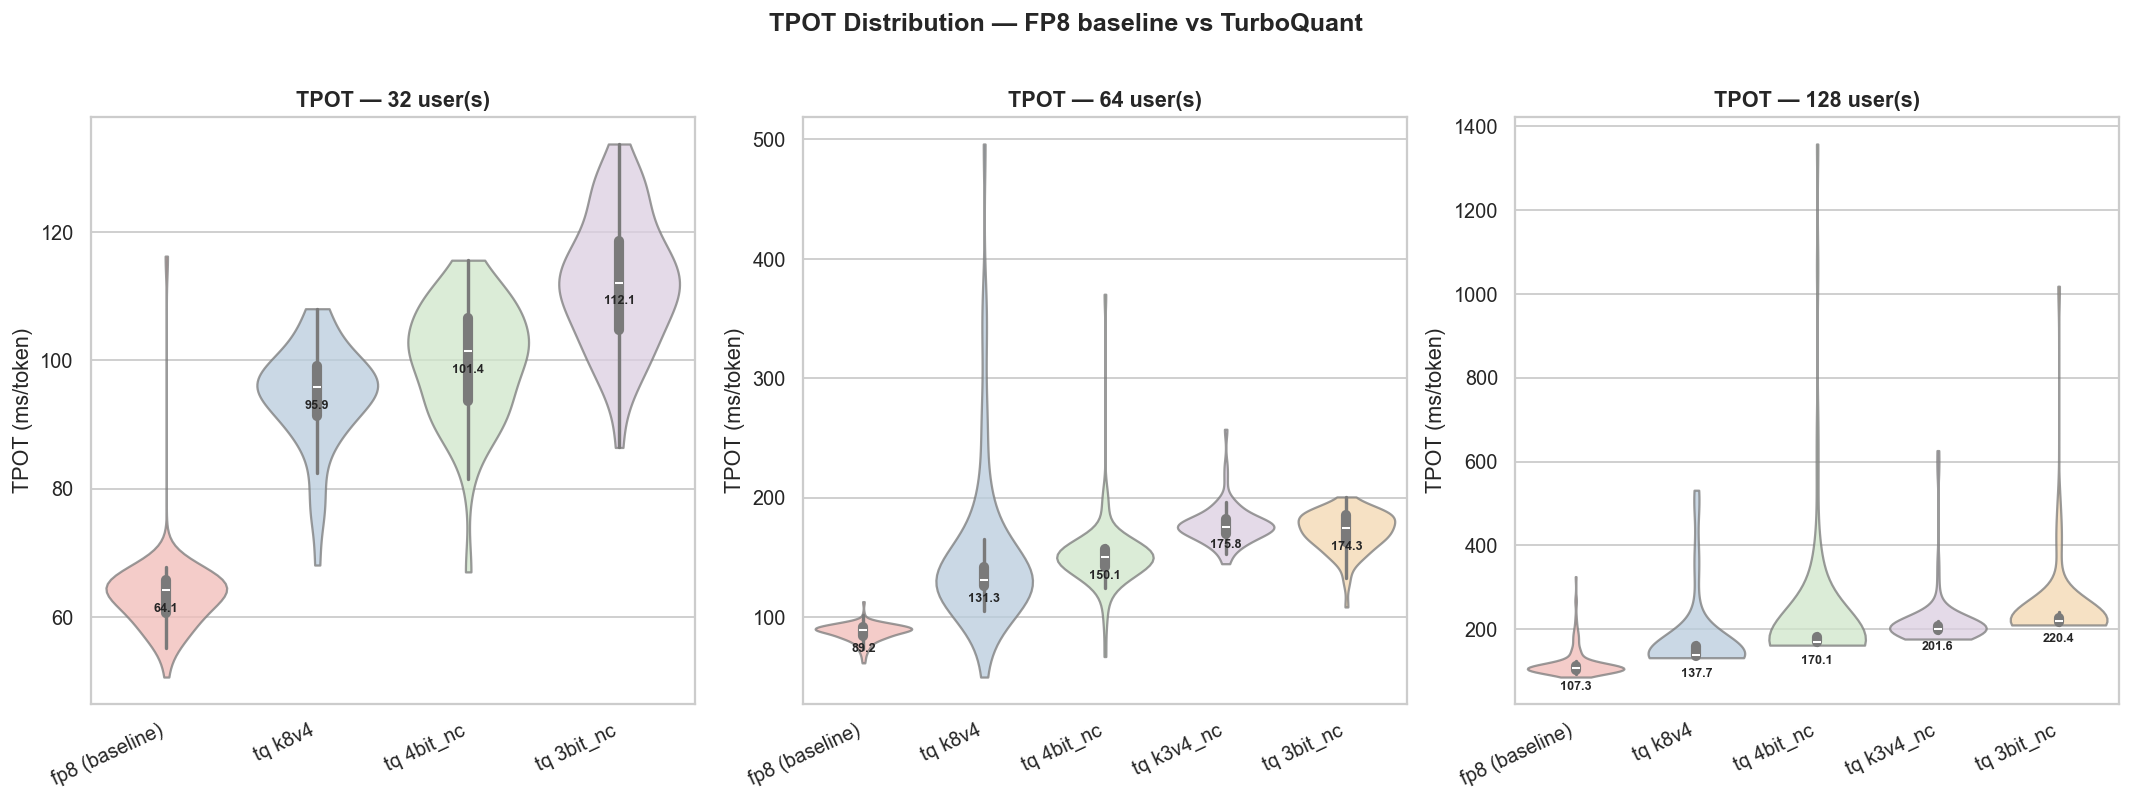

In [6]:
fig = violin_by_users(df_ok, 'tpot_ms', 'TPOT', 'TPOT (ms/token)', palette='Pastel1', fmt='{:.1f}')
plt.savefig(RESULTS_ROOT / 'turboquant_tpot_violin.png', bbox_inches='tight')
plt.show()

/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_35482/2656172228.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EXP_SHORT.get(e, e) for e in order], rotation=25, ha='right')
/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_35482/2656172228.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EXP_SHORT.get(e, e) for e in order], rotation=25, ha='right')
/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_35482/2656172228.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EXP_SHORT.get(e, e) for e in order], rotation=25, ha='right')


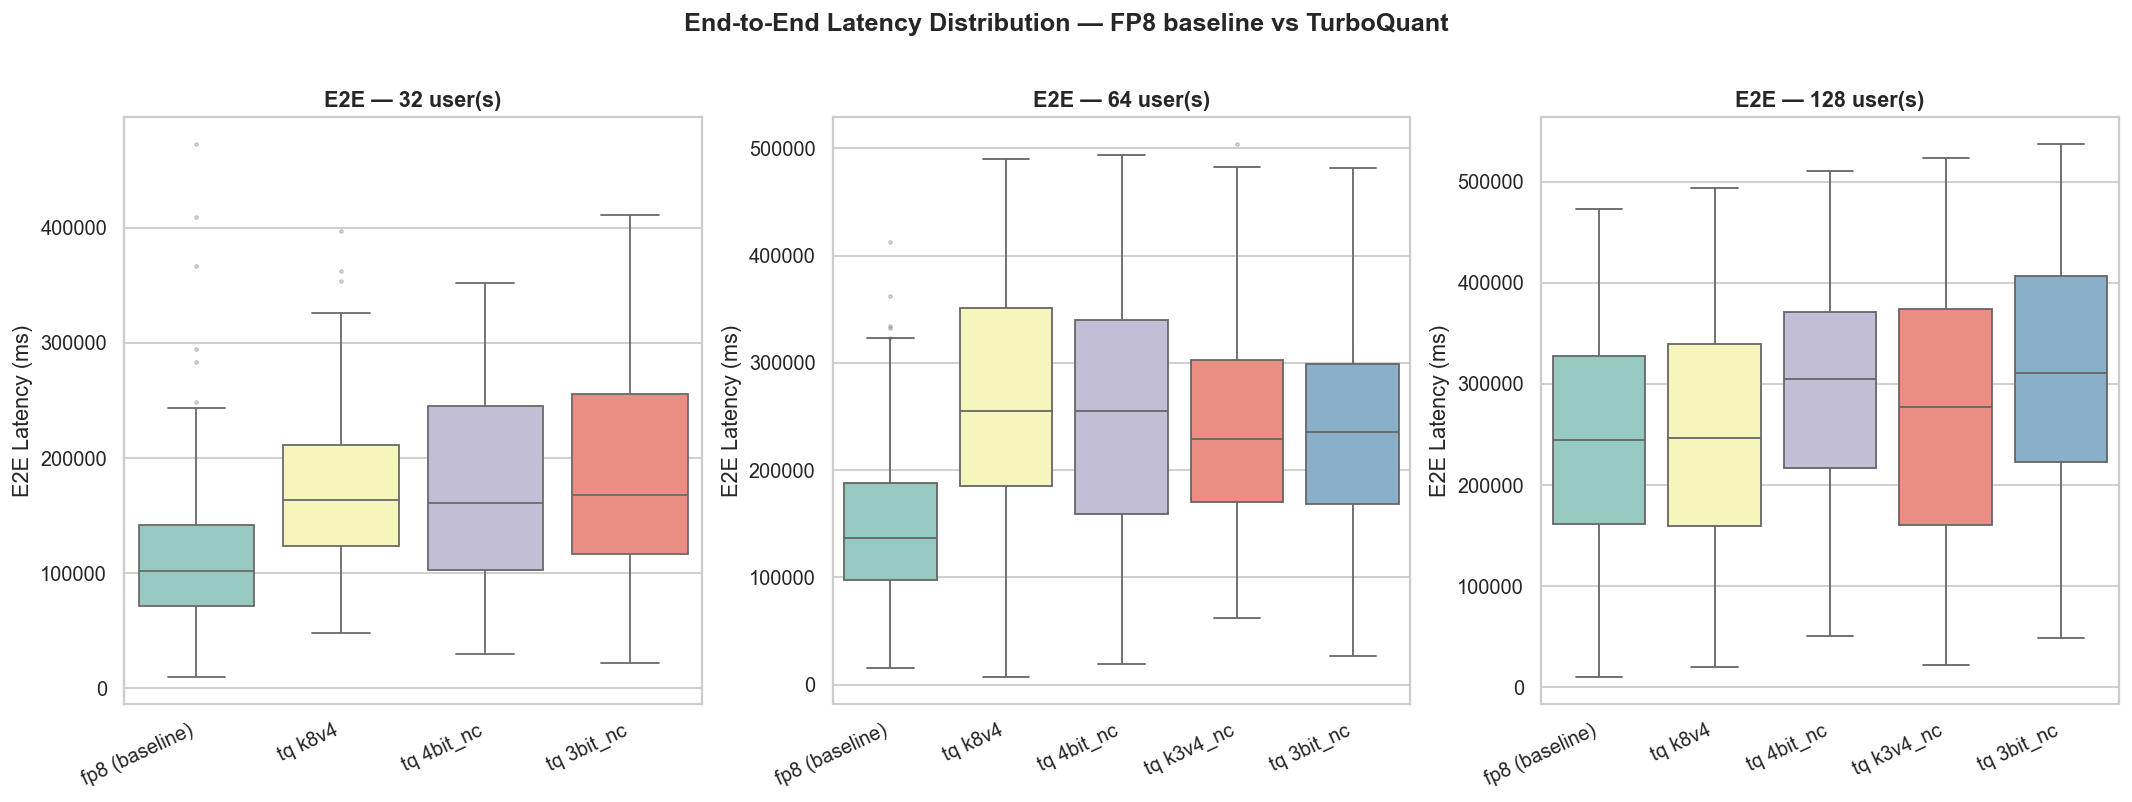

In [7]:
# ─── E2E latency: boxplot is cleaner for long tails ────────────────────────
user_levels = sorted(df_ok['users'].unique())
n_u = len(user_levels)
fig, axes = plt.subplots(1, n_u, figsize=(5.5 * n_u, 6), sharey=False)
if n_u == 1:
    axes = [axes]
for ax, u in zip(axes, user_levels):
    sub = df_ok[df_ok['users'] == u]
    order = [e for e in _exp_order_in(sub)]
    sns.boxplot(data=sub, x='experiment', y='e2e_ms', order=order,
                ax=ax, palette='Set3',
                flierprops=dict(marker='.', markersize=3, alpha=0.4))
    ax.set_title(f'E2E — {u} user(s)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('E2E Latency (ms)')
    ax.set_xticklabels([EXP_SHORT.get(e, e) for e in order], rotation=25, ha='right')
plt.suptitle('End-to-End Latency Distribution — FP8 baseline vs TurboQuant', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'turboquant_e2e_boxplot.png', bbox_inches='tight')
plt.show()

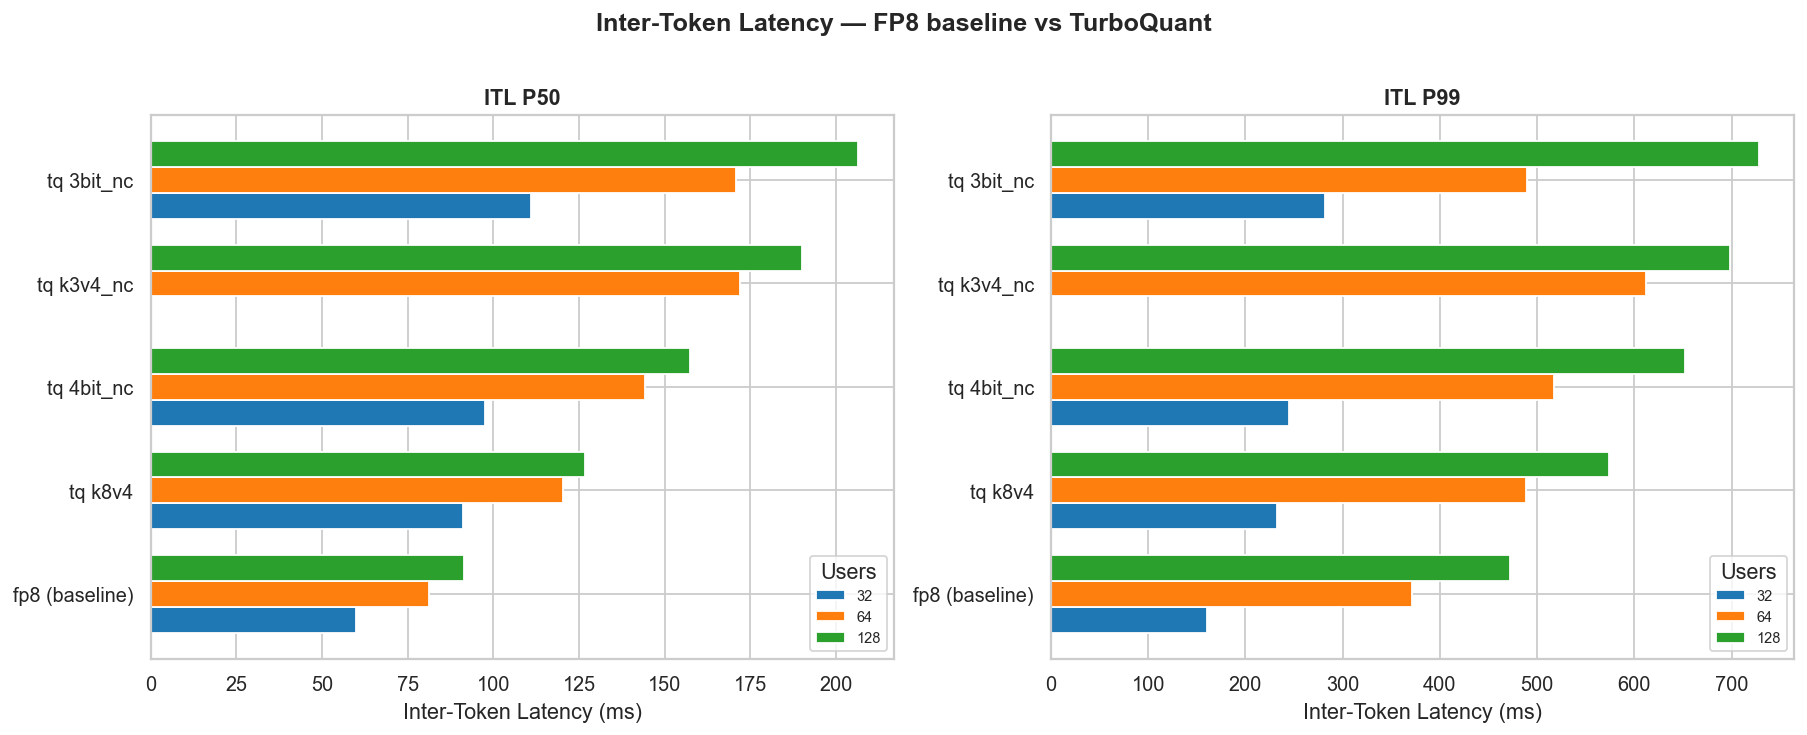

In [8]:
# ─── Inter-token latency (ITL) — P50 and P99 ───────────────────────────────
itl_agg = (
    df_ok.groupby(['experiment', 'users'])
    .agg(itl_p50=('itl_p50_ms', 'mean'), itl_p99=('itl_p99_ms', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, metric, title in zip(axes, ['itl_p50', 'itl_p99'], ['ITL P50', 'ITL P99']):
    pivot = itl_agg.pivot(index='experiment', columns='users', values=metric)
    pivot = pivot.reindex([e for e in EXP_ORDER if e in pivot.index])
    pivot.index = [EXP_SHORT.get(e, e) for e in pivot.index]
    pivot.plot(kind='barh', ax=ax, width=0.75)
    ax.set_xlabel('Inter-Token Latency (ms)')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('')
    ax.legend(title='Users', fontsize=8)

plt.suptitle('Inter-Token Latency — FP8 baseline vs TurboQuant', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'turboquant_itl_analysis.png', bbox_inches='tight')
plt.show()

## 4. Throughput vs latency — Pareto frontier

/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_35482/252513459.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pareto = df_ok.groupby(['experiment', 'users']).apply(compute_throughput).reset_index()


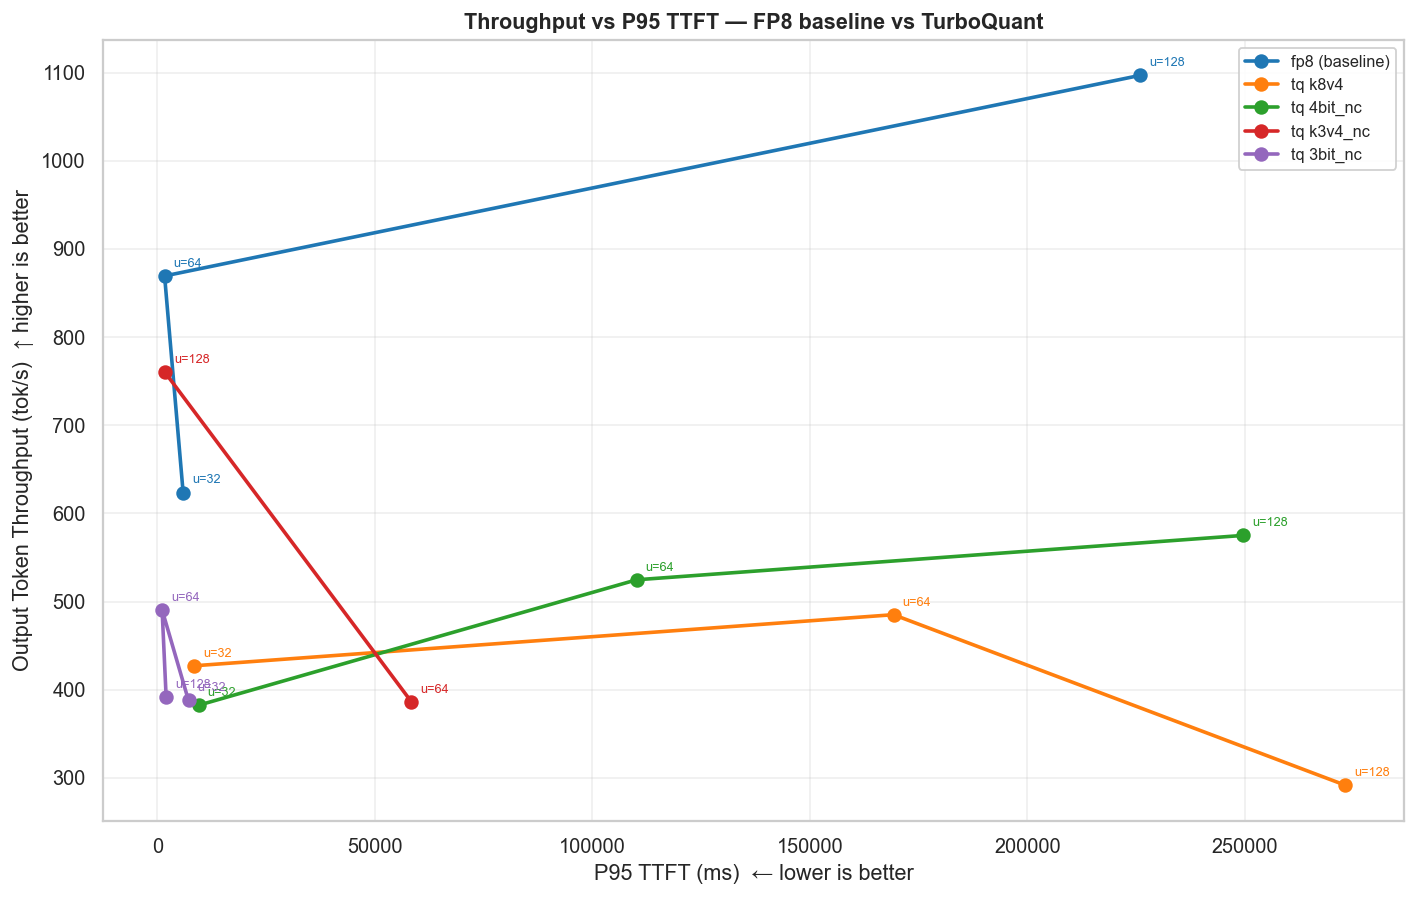

In [9]:
def compute_throughput(grp):
    total_tokens = grp['output_tokens'].sum()
    duration_s = grp['timestamp'].max() - grp['timestamp'].min()
    if duration_s < 1:
        duration_s = 1
    return pd.Series({
        'token_throughput': total_tokens / duration_s,
        'ttft_p95':         grp['ttft_ms'].quantile(0.95),
        'ttft_p50':         grp['ttft_ms'].quantile(0.50),
        'e2e_p95':          grp['e2e_ms'].quantile(0.95),
    })

pareto = df_ok.groupby(['experiment', 'users']).apply(compute_throughput).reset_index()

fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette('tab10', len(EXP_ORDER))

for exp, color in zip([e for e in EXP_ORDER if e in pareto['experiment'].unique()], palette):
    sub = pareto[pareto['experiment'] == exp].sort_values('users')
    ax.plot(sub['ttft_p95'], sub['token_throughput'],
            marker='o', label=EXP_SHORT.get(exp, exp), color=color, linewidth=2, markersize=7)
    for _, row in sub.iterrows():
        ax.annotate(f'u={int(row["users"])}', (row['ttft_p95'], row['token_throughput']),
                    textcoords='offset points', xytext=(5, 5), fontsize=7, color=color)

ax.set_xlabel('P95 TTFT (ms)  ← lower is better')
ax.set_ylabel('Output Token Throughput (tok/s)  ↑ higher is better')
ax.set_title('Throughput vs P95 TTFT — FP8 baseline vs TurboQuant', fontweight='bold')
ax.legend(loc='best', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'turboquant_pareto_frontier.png', bbox_inches='tight')
plt.show()

## 5. Latency heatmaps

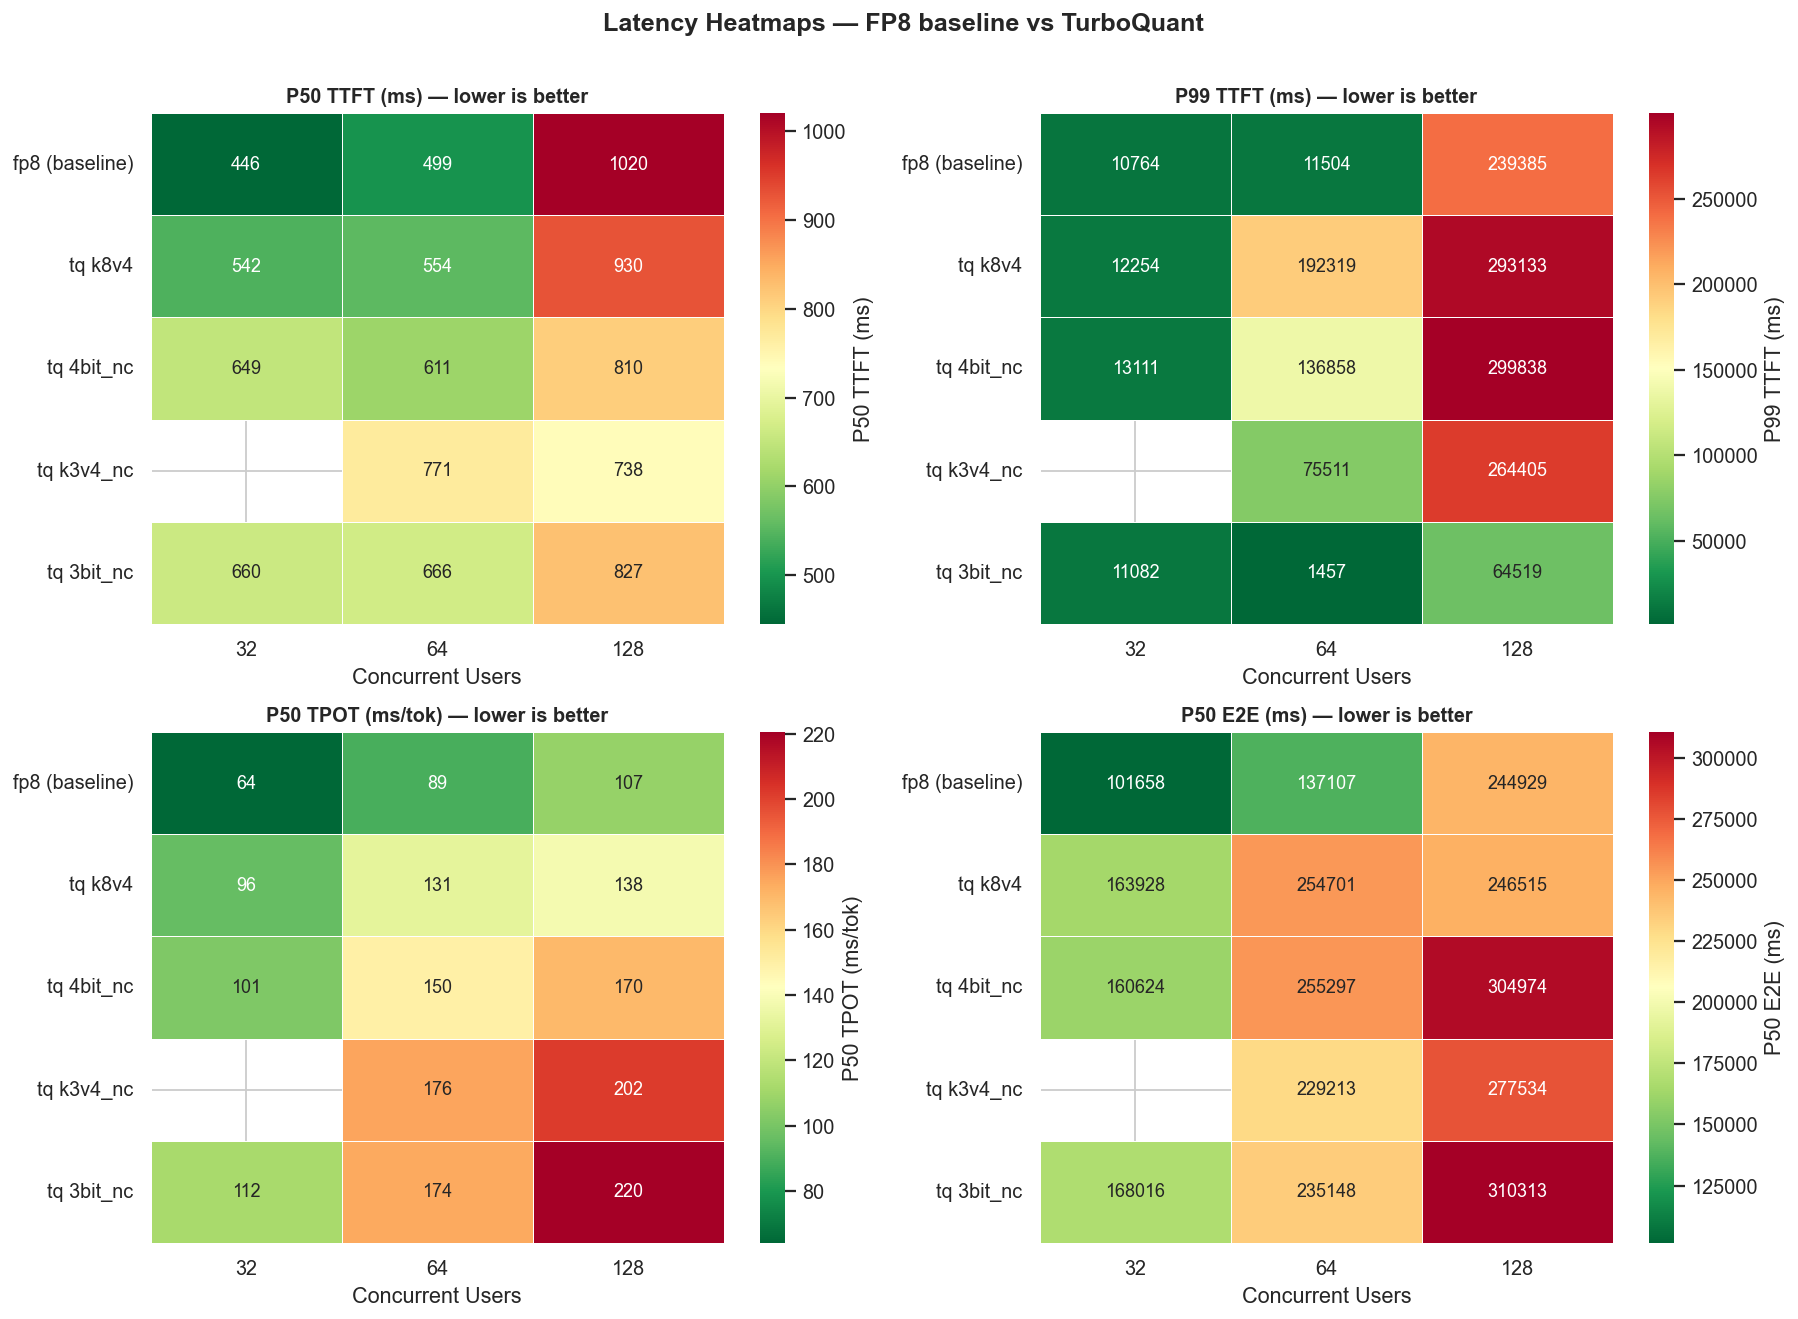

In [10]:
metrics_for_heatmap = [
    ('ttft_p50', 'P50 TTFT (ms)',     'RdYlGn_r'),
    ('ttft_p99', 'P99 TTFT (ms)',     'RdYlGn_r'),
    ('tpot_p50', 'P50 TPOT (ms/tok)', 'RdYlGn_r'),
    ('e2e_p50',  'P50 E2E (ms)',      'RdYlGn_r'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, title, cmap) in zip(axes.flat, metrics_for_heatmap):
    pivot = summary_agg.pivot_table(index='experiment', columns='users', values=col, aggfunc='mean')
    pivot = pivot.reindex([e for e in EXP_ORDER if e in pivot.index])
    pivot.index = [EXP_SHORT.get(e, e) for e in pivot.index]
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap=cmap,
                linewidths=0.5, ax=ax, cbar_kws={'label': title})
    ax.set_title(title + ' — lower is better', fontweight='bold', fontsize=11)
    ax.set_xlabel('Concurrent Users')
    ax.set_ylabel('')

plt.suptitle('Latency Heatmaps — FP8 baseline vs TurboQuant', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'turboquant_latency_heatmaps.png', bbox_inches='tight')
plt.show()

## 6. Percentage change vs FP8 baseline

Percentage change vs qwen3_kv_fp8_baseline (negative = improvement, positive = regression):


,experiment,users,ttft_p50_change_%,ttft_p99_change_%,tpot_p50_change_%,tpot_p99_change_%,e2e_p50_change_%,e2e_p99_change_%
0,qwen3_kv_turboquant_k8v4,32,+21.7%,+13.8%,+49.5%,+34.6%,+61.3%,-10.7%
1,qwen3_kv_turboquant_k8v4,64,+11.1%,+1571.8%,+47.2%,+300.4%,+85.8%,+37.6%
2,qwen3_kv_turboquant_k8v4,128,-8.8%,+22.5%,+28.3%,+93.0%,+0.6%,+4.5%
3,qwen3_kv_turboquant_4bit_nc,32,+45.7%,+21.8%,+58.1%,+43.3%,+58.0%,-17.3%
4,qwen3_kv_turboquant_4bit_nc,64,+22.4%,+1089.7%,+68.2%,+135.7%,+86.2%,+38.5%
5,qwen3_kv_turboquant_4bit_nc,128,-20.5%,+25.3%,+58.6%,+314.9%,+24.5%,+7.8%
6,qwen3_kv_turboquant_k3v4_nc,64,+54.4%,+556.4%,+97.0%,+134.9%,+67.2%,+37.7%
7,qwen3_kv_turboquant_k3v4_nc,128,-27.6%,+10.5%,+88.0%,+121.5%,+13.3%,+10.0%
8,qwen3_kv_turboquant_3bit_nc,32,+48.1%,+3.0%,+74.8%,+64.2%,+65.3%,-4.2%
9,qwen3_kv_turboquant_3bit_nc,64,+33.4%,-87.3%,+95.4%,+96.6%,+71.5%,+31.3%


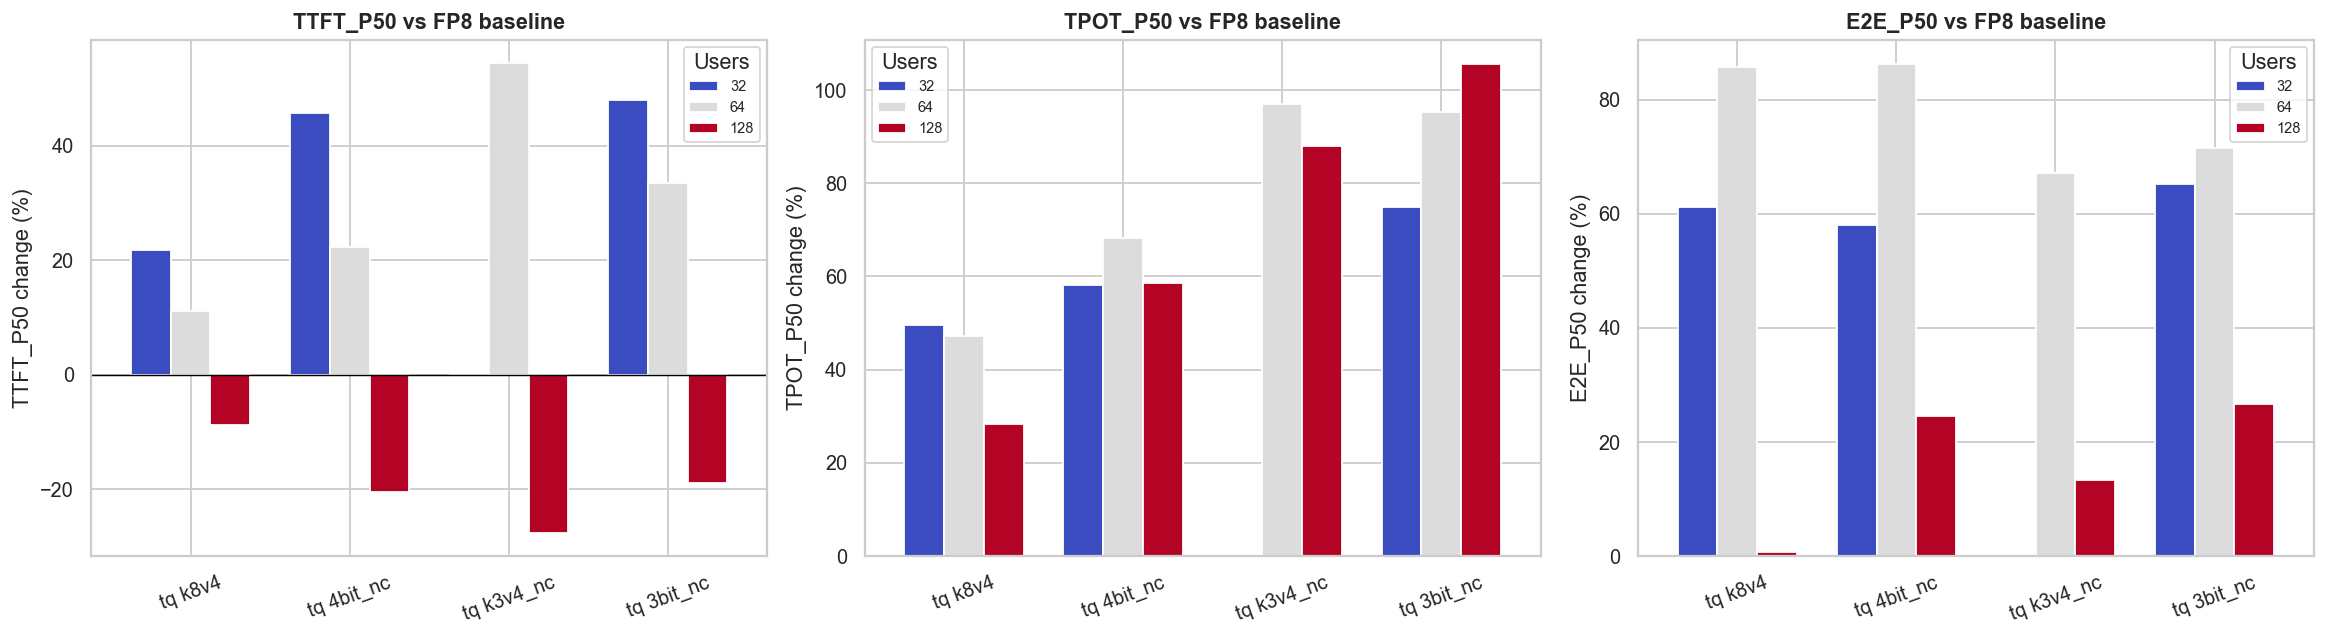

In [11]:
base = summary_agg[summary_agg['experiment'] == BASELINE_EXP].set_index('users')
rows = []
for exp in [e for e in EXP_ORDER if e != BASELINE_EXP and e in summary_agg['experiment'].unique()]:
    comp = summary_agg[summary_agg['experiment'] == exp].set_index('users')
    for u in comp.index.intersection(base.index):
        b, c = base.loc[u], comp.loc[u]
        rows.append({
            'experiment':         exp,
            'users':              u,
            'ttft_p50_change_%':  (c['ttft_p50'] - b['ttft_p50']) / b['ttft_p50'] * 100,
            'ttft_p99_change_%':  (c['ttft_p99'] - b['ttft_p99']) / b['ttft_p99'] * 100,
            'tpot_p50_change_%':  (c['tpot_p50'] - b['tpot_p50']) / b['tpot_p50'] * 100,
            'tpot_p99_change_%':  (c['tpot_p99'] - b['tpot_p99']) / b['tpot_p99'] * 100,
            'e2e_p50_change_%':   (c['e2e_p50']  - b['e2e_p50'])  / b['e2e_p50']  * 100,
            'e2e_p99_change_%':   (c['e2e_p99']  - b['e2e_p99'])  / b['e2e_p99']  * 100,
        })

imp_df = pd.DataFrame(rows)
print(f'Percentage change vs {BASELINE_EXP} (negative = improvement, positive = regression):')
display(imp_df.style.format({c: '{:+.1f}%' for c in imp_df.columns if c.endswith('_change_%')})
        .map(lambda v: 'color: green' if isinstance(v, str) and v.startswith('-')
             else ('color: red' if isinstance(v, str) and v.startswith('+') else ''),
             subset=[c for c in imp_df.columns if c.endswith('_change_%')]))

# ─── Bar chart per metric ──────────────────────────────────────────────────
metrics_to_plot = ['ttft_p50_change_%', 'tpot_p50_change_%', 'e2e_p50_change_%']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(6 * len(metrics_to_plot), 5), sharey=False)
for ax, metric in zip(axes, metrics_to_plot):
    pivot = imp_df.pivot(index='experiment', columns='users', values=metric)
    pivot = pivot.reindex([e for e in EXP_ORDER if e in pivot.index])
    pivot.index = [EXP_SHORT.get(e, e) for e in pivot.index]
    pivot.plot(kind='bar', ax=ax, width=0.75, colormap='coolwarm')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel(f'{metric.replace("_change_%", "").upper()} change (%)')
    ax.set_title(f'{metric.replace("_change_%", "").upper()} vs FP8 baseline', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Users', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'turboquant_pct_change_vs_baseline.png', bbox_inches='tight')
plt.show()

## 7. Cost per million output tokens

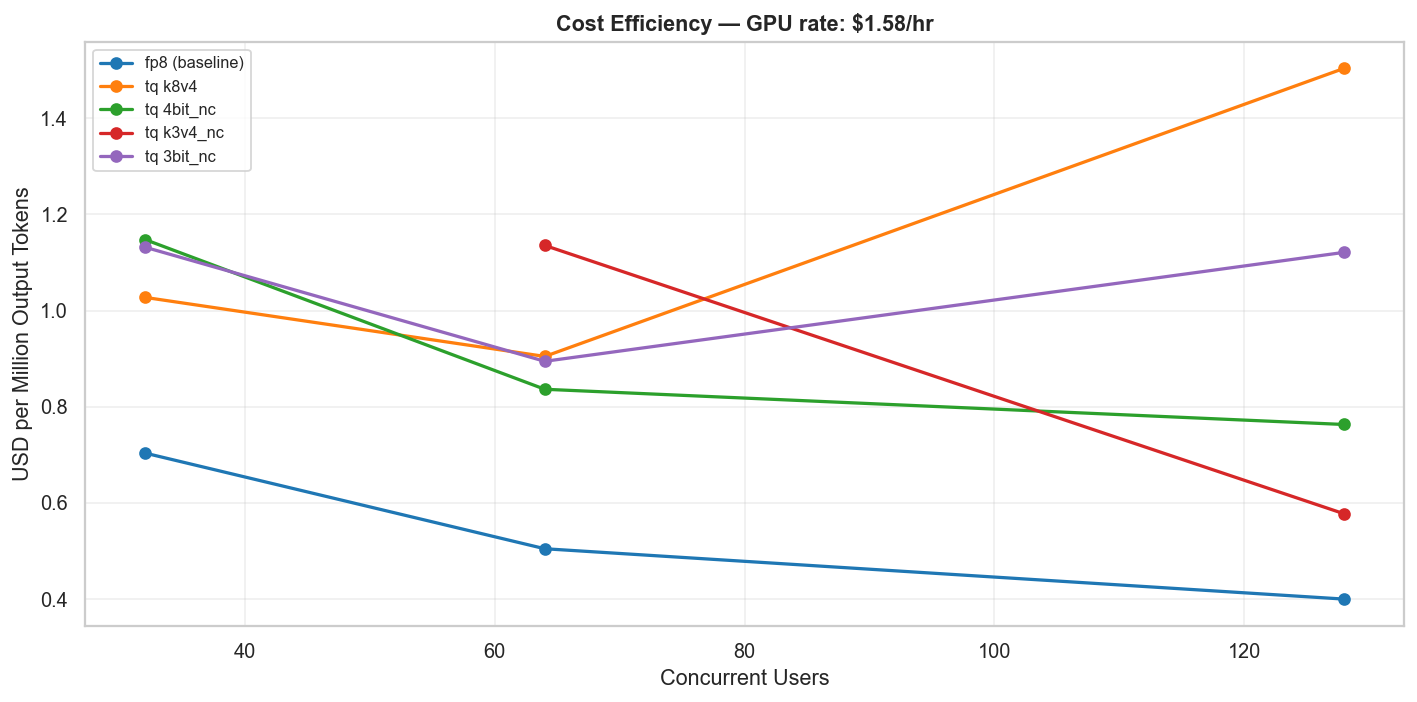

,experiment,users,total_tokens,duration_s,cost_per_M_tokens
0,qwen3_kv_fp8_baseline,32,"147,636",237s,$0.70
1,qwen3_kv_fp8_baseline,64,"208,868",240s,$0.50
2,qwen3_kv_fp8_baseline,128,"243,524",222s,$0.40
11,qwen3_kv_turboquant_k8v4,32,"96,893",227s,$1.03
12,qwen3_kv_turboquant_k8v4,64,"112,292",231s,$0.90
13,qwen3_kv_turboquant_k8v4,128,"48,470",166s,$1.50
6,qwen3_kv_turboquant_4bit_nc,32,"89,093",233s,$1.15
7,qwen3_kv_turboquant_4bit_nc,64,"125,470",239s,$0.84
8,qwen3_kv_turboquant_4bit_nc,128,"119,278",207s,$0.76
9,qwen3_kv_turboquant_k3v4_nc,64,"87,434",226s,$1.14


In [12]:
cost_rows = []
for (exp, users), grp in df_ok.groupby(['experiment', 'users']):
    total_tokens = grp['output_tokens'].sum()
    duration_hr  = (grp['timestamp'].max() - grp['timestamp'].min()) / 3600
    if duration_hr < 1e-6 or total_tokens == 0:
        continue
    cost_per_m = (GPU_HOURLY_COST_USD * duration_hr) / (total_tokens / 1_000_000)
    cost_rows.append({
        'experiment':        exp,
        'users':             users,
        'total_tokens':      total_tokens,
        'duration_s':        duration_hr * 3600,
        'cost_per_M_tokens': cost_per_m,
    })

cost_df = pd.DataFrame(cost_rows)
cost_df['experiment'] = pd.Categorical(cost_df['experiment'], categories=EXP_ORDER, ordered=True)
cost_df = cost_df.sort_values(['experiment', 'users'])

fig, ax = plt.subplots(figsize=(11, 5.5))
for exp in [e for e in EXP_ORDER if e in cost_df['experiment'].unique()]:
    sub = cost_df[cost_df['experiment'] == exp]
    ax.plot(sub['users'], sub['cost_per_M_tokens'], marker='o',
            label=EXP_SHORT.get(exp, exp), linewidth=1.8)

ax.set_xlabel('Concurrent Users')
ax.set_ylabel('USD per Million Output Tokens')
ax.set_title(f'Cost Efficiency — GPU rate: ${GPU_HOURLY_COST_USD}/hr', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'turboquant_cost_per_token.png', bbox_inches='tight')
plt.show()

display(cost_df.style.format({
    'cost_per_M_tokens': '${:.2f}',
    'duration_s':        '{:.0f}s',
    'total_tokens':      '{:,}',
}))

## 8. Server-side metrics (Prometheus)

GPU utilization, VRAM, KV-cache pressure, queue depth and generation throughput as observed on the vLLM pod during each (experiment, concurrency) cell.

In [13]:
def pivot_prometheus(prom_df: pd.DataFrame) -> pd.DataFrame:
    if prom_df.empty:
        return pd.DataFrame()
    pdf = prom_df.copy()
    pdf['value'] = pd.to_numeric(pdf['value'], errors='coerce')
    wide = pdf.pivot_table(
        index=['experiment', 'users', 'run', 'timestamp'],
        columns='metric_name',
        values='value',
        aggfunc='first',
    ).reset_index()
    wide.columns.name = None
    return wide

prom_wide = pivot_prometheus(prom_all)
prom_wide = prom_wide[prom_wide['experiment'].isin(EXP_ORDER)].copy()
if not prom_wide.empty:
    prom_wide['elapsed_s'] = prom_wide.groupby(['experiment', 'users'])['timestamp'].transform(
        lambda x: x - x.min()
    )

print(f'Prometheus wide: {len(prom_wide):,} rows')
available = [c for c in prom_wide.columns if c not in ['experiment','users','run','timestamp','elapsed_s']]
print(f'Available metrics: {available}')

Prometheus wide: 515 rows
Available metrics: ['container_cpu_cores', 'container_mem_bytes', 'e2e_p50_ms', 'e2e_p95_ms', 'e2e_p99_ms', 'generation_tokens_per_sec', 'gpu_fb_used_mib', 'gpu_util_pct', 'itl_p50_ms', 'itl_p95_ms', 'itl_p99_ms', 'kv_cache_usage_pct', 'preemptions_per_sec', 'prefix_cache_hits_per_sec', 'prefix_cache_queries_per_sec', 'prompt_tokens_per_sec', 'request_success_per_sec', 'requests_running', 'requests_waiting', 'tpot_p50_ms', 'tpot_p95_ms', 'tpot_p99_ms', 'ttft_p50_ms', 'ttft_p95_ms', 'ttft_p99_ms']


In [14]:
# ─── Server-side aggregate summary ─────────────────────────────────────────
agg_cols = {}
if 'gpu_util_pct'              in prom_wide.columns: agg_cols['gpu_util_mean']         = ('gpu_util_pct', 'mean')
if 'gpu_util_pct'              in prom_wide.columns: agg_cols['gpu_util_max']          = ('gpu_util_pct', 'max')
if 'gpu_fb_used_mib'           in prom_wide.columns: agg_cols['vram_mean_mib']         = ('gpu_fb_used_mib', 'mean')
if 'gpu_fb_used_mib'           in prom_wide.columns: agg_cols['vram_max_mib']          = ('gpu_fb_used_mib', 'max')
if 'kv_cache_usage_pct'        in prom_wide.columns: agg_cols['kv_cache_mean_pct']     = ('kv_cache_usage_pct', 'mean')
if 'kv_cache_usage_pct'        in prom_wide.columns: agg_cols['kv_cache_max_pct']      = ('kv_cache_usage_pct', 'max')
if 'requests_running'          in prom_wide.columns: agg_cols['requests_running_mean'] = ('requests_running', 'mean')
if 'requests_waiting'          in prom_wide.columns: agg_cols['requests_waiting_mean'] = ('requests_waiting', 'mean')
if 'requests_waiting'          in prom_wide.columns: agg_cols['requests_waiting_max']  = ('requests_waiting', 'max')
if 'generation_tokens_per_sec' in prom_wide.columns: agg_cols['gen_throughput_mean']   = ('generation_tokens_per_sec', 'mean')

server_summary = (
    prom_wide.groupby(['experiment', 'users'])
    .agg(**agg_cols)
    .reset_index()
)
server_summary['experiment'] = pd.Categorical(server_summary['experiment'], categories=EXP_ORDER, ordered=True)
server_summary = server_summary.sort_values(['experiment', 'users']).reset_index(drop=True)

pd.set_option('display.float_format', '{:.1f}'.format)
print('Server-side summary:')
display(server_summary)

Server-side summary:


,experiment,users,gpu_util_mean,gpu_util_max,vram_mean_mib,vram_max_mib,kv_cache_mean_pct,kv_cache_max_pct,requests_running_mean,requests_waiting_mean,requests_waiting_max,gen_throughput_mean
0,qwen3_kv_fp8_baseline,32,98.2,100.0,20631.7,20648.0,0.3,0.6,17.5,0.0,0.0,288.3
1,qwen3_kv_fp8_baseline,64,97.3,100.0,20648.0,20648.0,0.6,1.0,36.8,0.3,5.0,435.4
2,qwen3_kv_fp8_baseline,128,100.0,100.0,20648.0,20648.0,0.9,1.0,57.4,38.5,73.0,539.6
3,qwen3_kv_turboquant_k8v4,32,97.2,100.0,20225.4,20228.0,0.5,0.9,18.5,0.0,0.0,203.7
4,qwen3_kv_turboquant_k8v4,64,97.3,100.0,20228.0,20228.0,0.9,1.0,33.6,11.3,35.0,263.1
5,qwen3_kv_turboquant_k8v4,128,91.1,100.0,20228.0,20228.0,0.9,1.0,36.4,54.6,96.0,266.3
6,qwen3_kv_turboquant_4bit_nc,32,97.2,100.0,20204.0,20204.0,0.4,0.7,17.6,0.0,0.0,186.0
7,qwen3_kv_turboquant_4bit_nc,64,97.1,100.0,20204.0,20204.0,0.8,1.0,40.4,4.8,24.0,270.9
8,qwen3_kv_turboquant_4bit_nc,128,91.2,100.0,20204.0,20204.0,0.9,1.0,51.9,39.4,80.0,300.7
9,qwen3_kv_turboquant_k3v4_nc,64,94.5,100.0,20224.0,20224.0,0.8,1.0,44.0,2.2,11.0,253.8


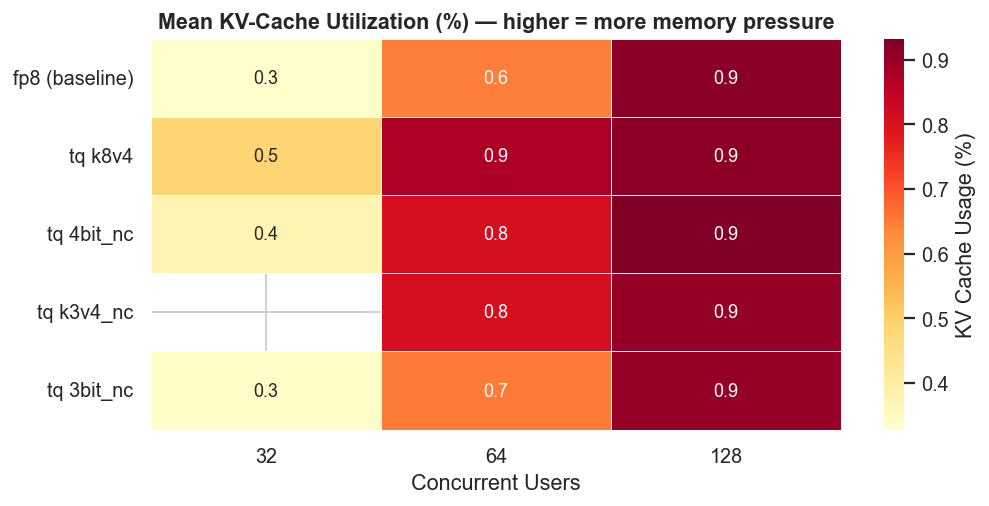

In [15]:
# ─── KV cache usage heatmap ────────────────────────────────────────────────
if 'kv_cache_mean_pct' in server_summary.columns:
    pivot_kv = server_summary.pivot_table(
        index='experiment', columns='users', values='kv_cache_mean_pct', aggfunc='mean'
    )
    pivot_kv = pivot_kv.reindex([e for e in EXP_ORDER if e in pivot_kv.index])
    pivot_kv.index = [EXP_SHORT.get(e, e) for e in pivot_kv.index]
    fig, ax = plt.subplots(figsize=(max(8, pivot_kv.shape[1] * 2), max(4, pivot_kv.shape[0] * 0.7)))
    sns.heatmap(pivot_kv, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'KV Cache Usage (%)'})
    ax.set_title('Mean KV-Cache Utilization (%) — higher = more memory pressure', fontweight='bold')
    ax.set_xlabel('Concurrent Users')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / 'turboquant_kv_cache_heatmap.png', bbox_inches='tight')
    plt.show()

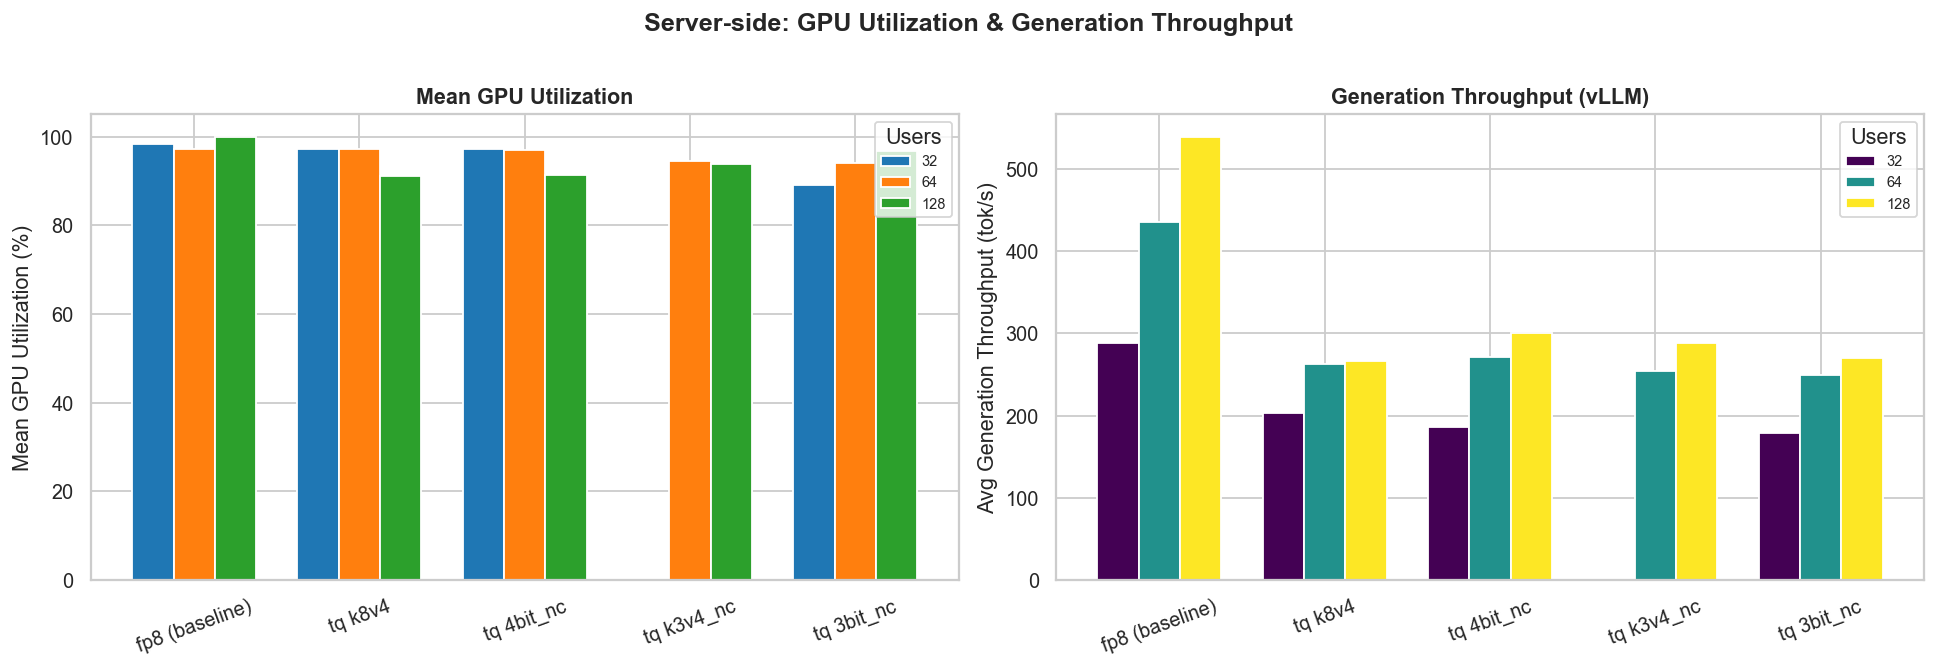

In [16]:
# ─── GPU util + Generation throughput bars ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if 'gpu_util_mean' in server_summary.columns:
    p = server_summary.pivot(index='experiment', columns='users', values='gpu_util_mean')
    p = p.reindex([e for e in EXP_ORDER if e in p.index])
    p.index = [EXP_SHORT.get(e, e) for e in p.index]
    p.plot(kind='bar', ax=axes[0], width=0.75)
    axes[0].set_ylabel('Mean GPU Utilization (%)')
    axes[0].set_ylim(0, 105)
    axes[0].set_xlabel('')
    axes[0].set_title('Mean GPU Utilization', fontweight='bold')
    axes[0].legend(title='Users', fontsize=8)
    axes[0].tick_params(axis='x', rotation=20)

if 'gen_throughput_mean' in server_summary.columns:
    p = server_summary.pivot(index='experiment', columns='users', values='gen_throughput_mean')
    p = p.reindex([e for e in EXP_ORDER if e in p.index])
    p.index = [EXP_SHORT.get(e, e) for e in p.index]
    p.plot(kind='bar', ax=axes[1], width=0.75, colormap='viridis')
    axes[1].set_ylabel('Avg Generation Throughput (tok/s)')
    axes[1].set_xlabel('')
    axes[1].set_title('Generation Throughput (vLLM)', fontweight='bold')
    axes[1].legend(title='Users', fontsize=8)
    axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Server-side: GPU Utilization & Generation Throughput', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'turboquant_server_bars.png', bbox_inches='tight')
plt.show()

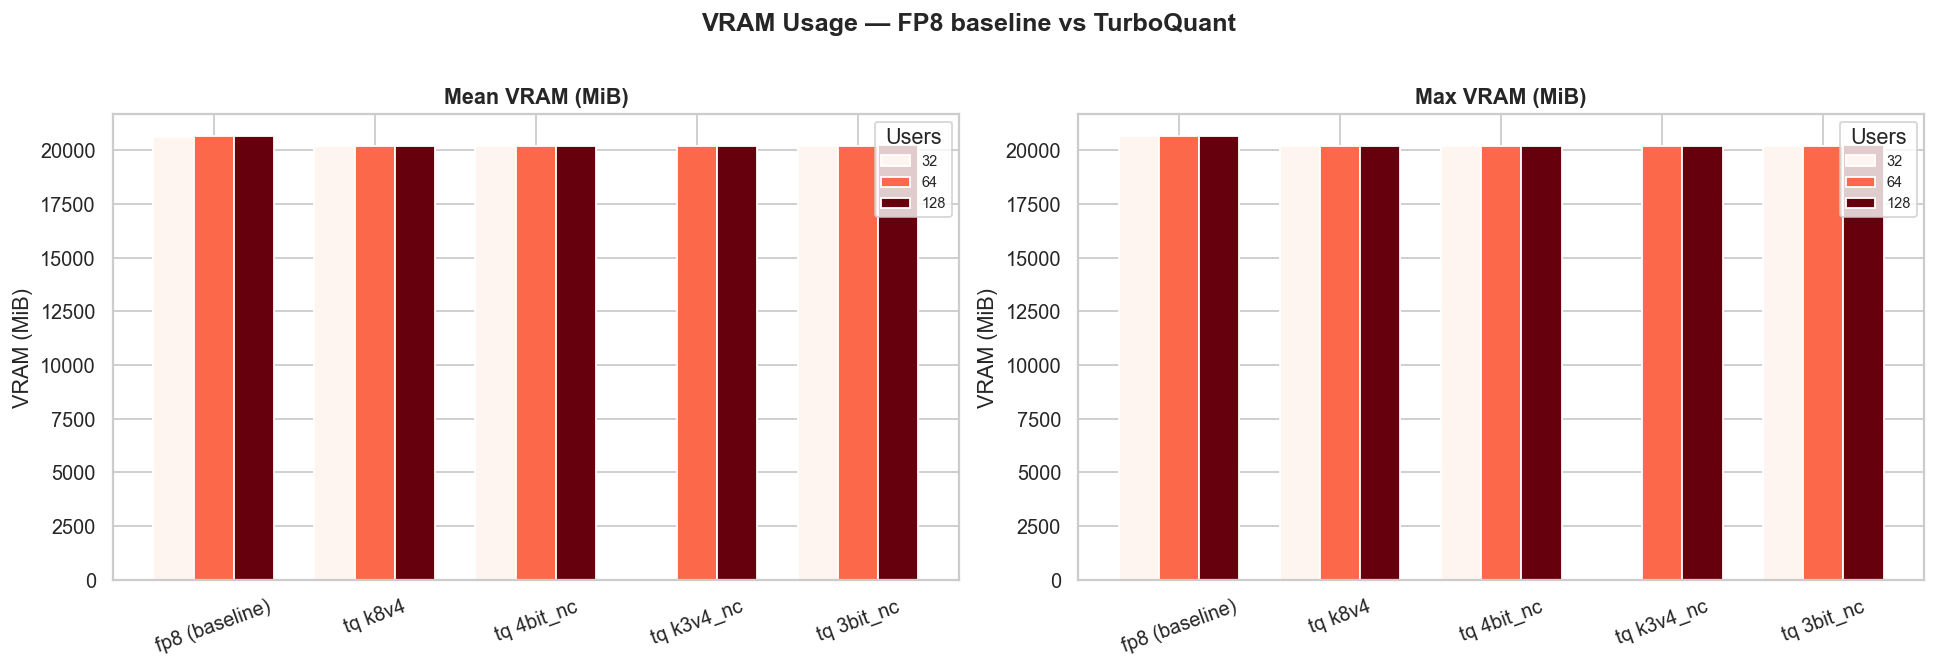

In [17]:
# ─── VRAM comparison (mean and max) ────────────────────────────────────────
if 'vram_mean_mib' in server_summary.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, col, title in zip(axes, ['vram_mean_mib', 'vram_max_mib'], ['Mean VRAM (MiB)', 'Max VRAM (MiB)']):
        p = server_summary.pivot(index='experiment', columns='users', values=col)
        p = p.reindex([e for e in EXP_ORDER if e in p.index])
        p.index = [EXP_SHORT.get(e, e) for e in p.index]
        p.plot(kind='bar', ax=ax, width=0.75, colormap='Reds')
        ax.set_ylabel('VRAM (MiB)')
        ax.set_xlabel('')
        ax.set_title(title, fontweight='bold')
        ax.legend(title='Users', fontsize=8)
        ax.tick_params(axis='x', rotation=20)
    plt.suptitle('VRAM Usage — FP8 baseline vs TurboQuant', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / 'turboquant_vram.png', bbox_inches='tight')
    plt.show()

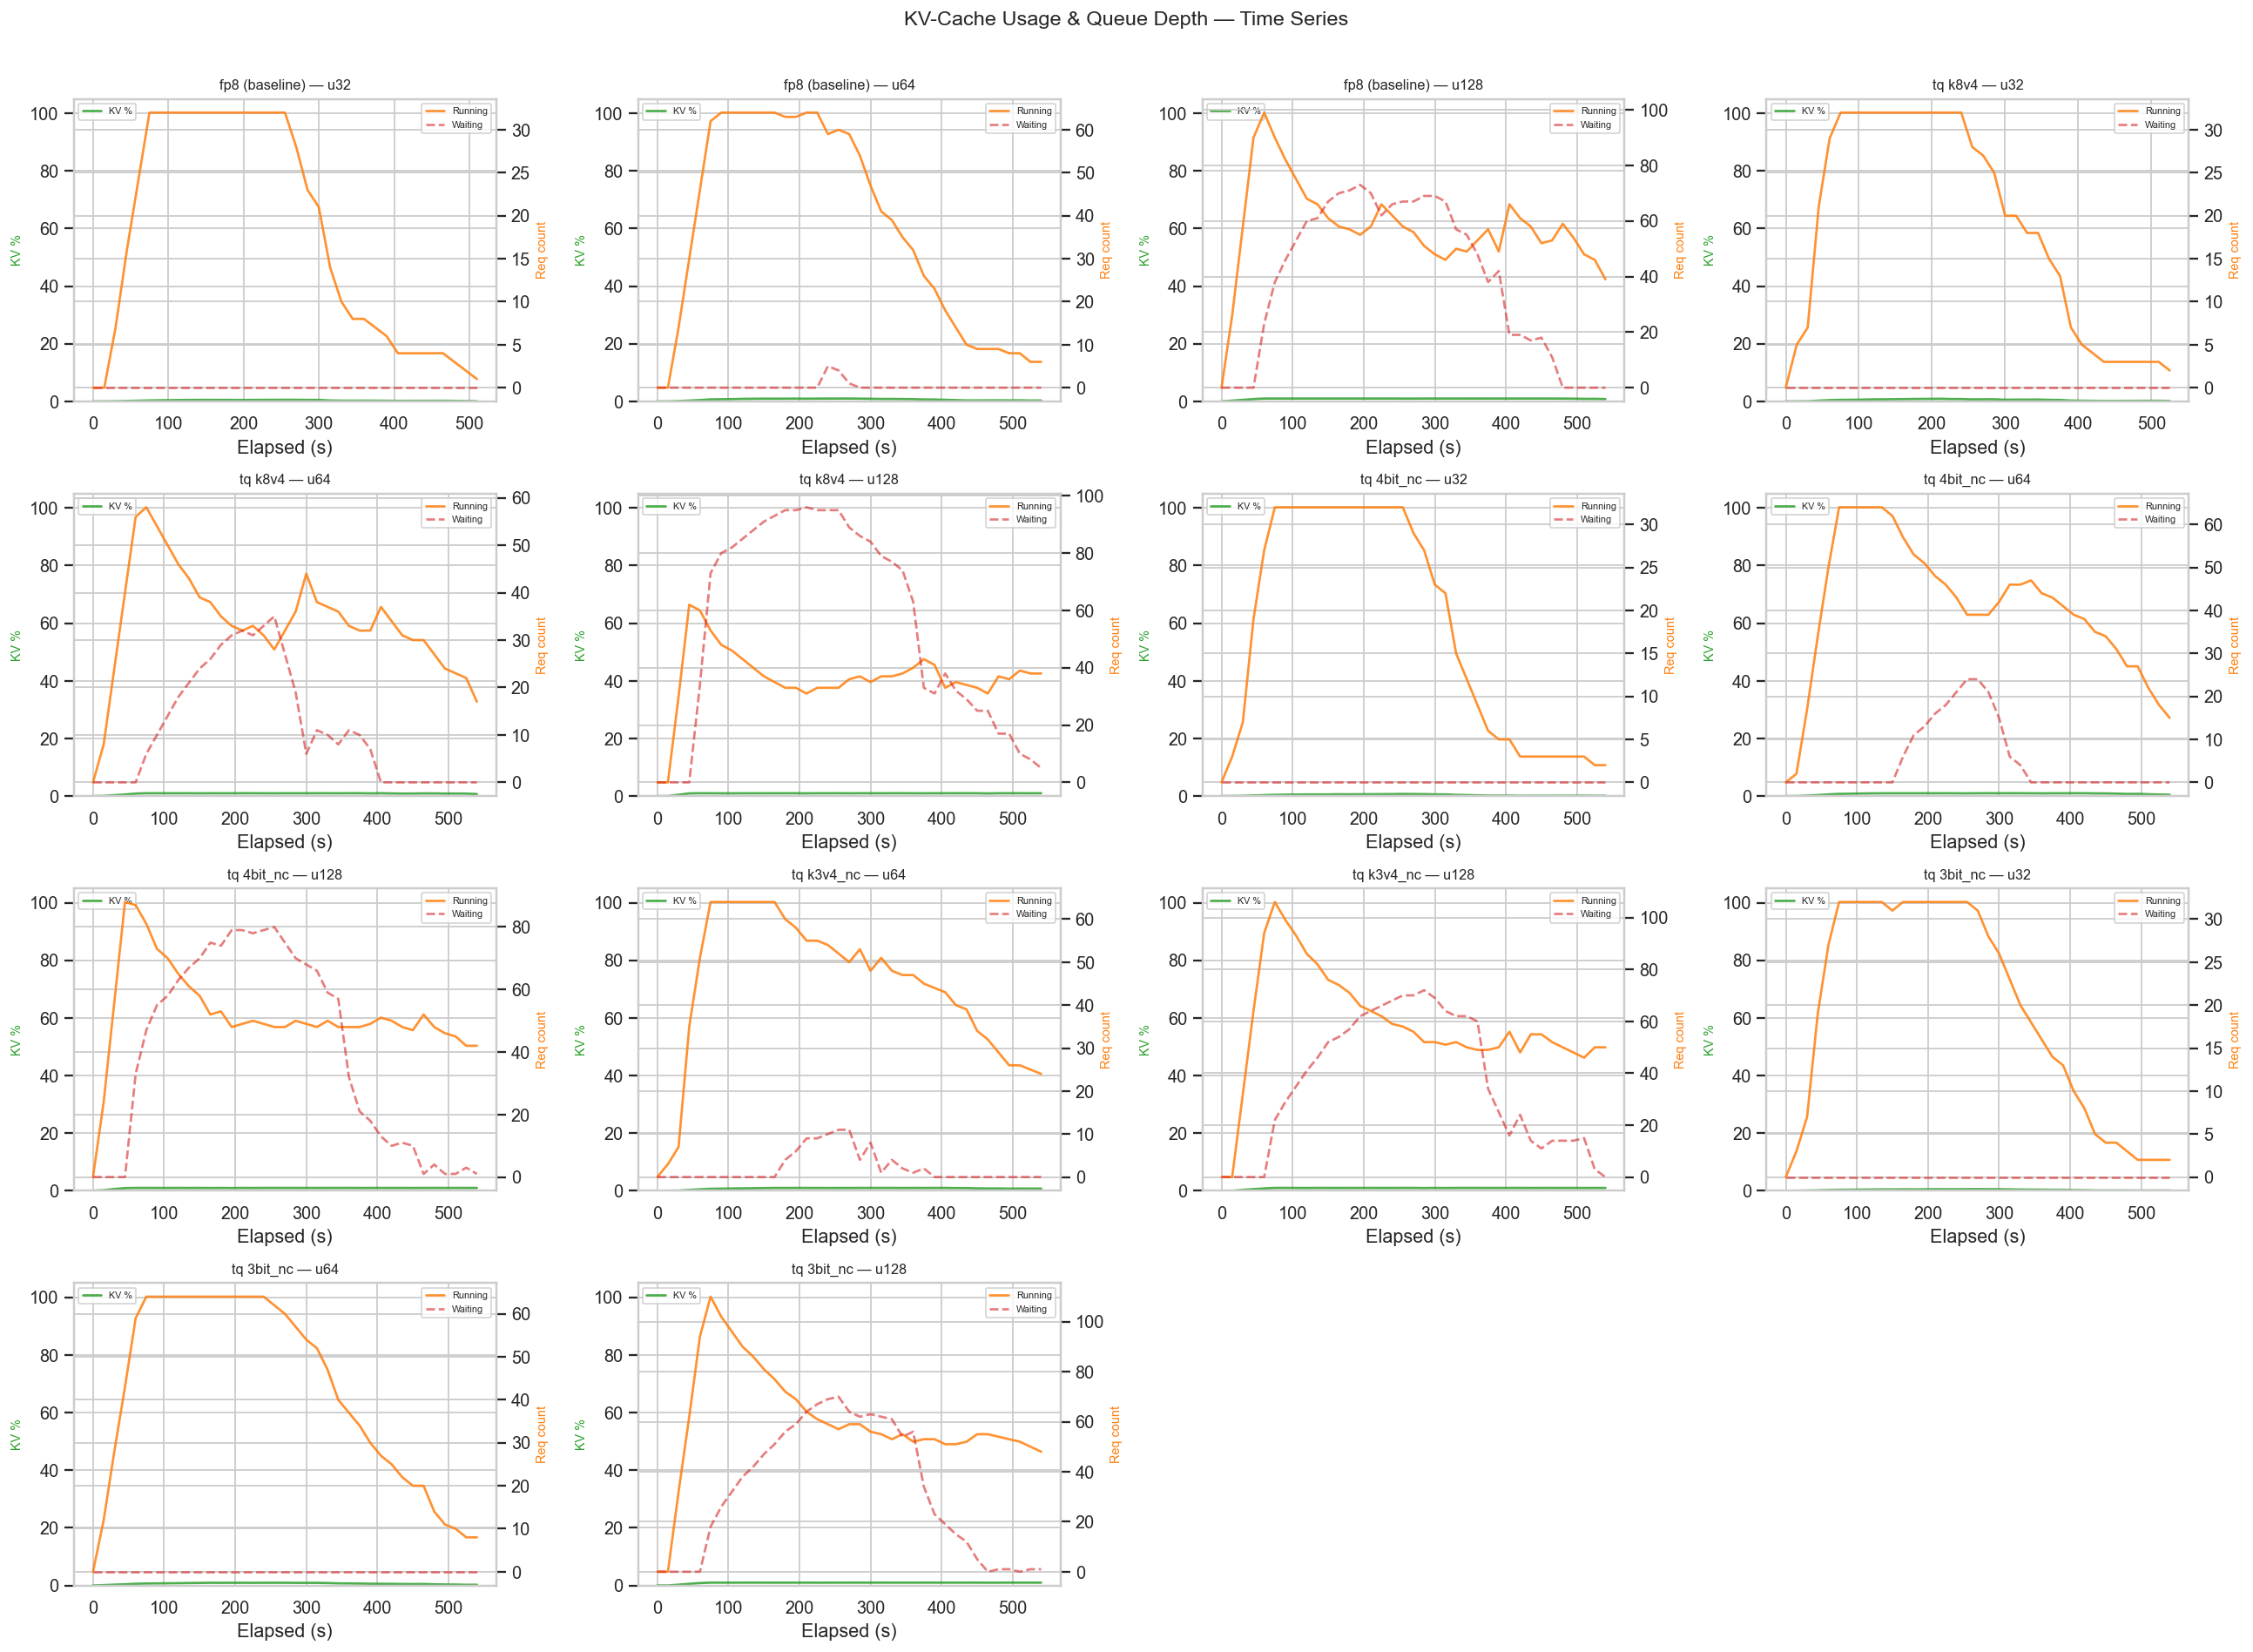

In [18]:
# ─── KV-cache & queue depth time series — one panel per (experiment, users) ─
if not prom_wide.empty and 'kv_cache_usage_pct' in prom_wide.columns:
    combos = prom_wide.groupby(['experiment', 'users']).ngroups
    n_cols = min(4, combos)
    n_rows = (combos + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.6 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    ordered_groups = sorted(
        prom_wide.groupby(['experiment', 'users']),
        key=lambda kv: (EXP_ORDER.index(kv[0][0]) if kv[0][0] in EXP_ORDER else 99, kv[0][1]),
    )

    for idx, ((exp, u), grp) in enumerate(ordered_groups):
        if idx >= len(axes_flat):
            break
        ax = axes_flat[idx]
        ax2 = ax.twinx()
        ax.plot(grp['elapsed_s'], grp['kv_cache_usage_pct'], color='tab:green', alpha=0.85, label='KV %')
        if 'requests_running' in grp.columns:
            ax2.plot(grp['elapsed_s'], grp['requests_running'], color='tab:orange', alpha=0.85, label='Running')
        if 'requests_waiting' in grp.columns:
            ax2.plot(grp['elapsed_s'], grp['requests_waiting'], color='tab:red', alpha=0.6, linestyle='--', label='Waiting')
        ax.set_ylim(0, 105)
        ax.set_ylabel('KV %', color='tab:green', fontsize=8)
        ax2.set_ylabel('Req count', color='tab:orange', fontsize=8)
        ax.set_xlabel('Elapsed (s)')
        ax.set_title(f'{EXP_SHORT.get(exp, exp)} — u{u}', fontsize=9)
        ax.legend(loc='upper left', fontsize=6)
        ax2.legend(loc='upper right', fontsize=6)

    for j in range(idx + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle('KV-Cache Usage & Queue Depth — Time Series', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / 'turboquant_kv_queue_timeseries.png', bbox_inches='tight')
    plt.show()

## 9. Quality evaluation — `arc_challenge` & `gsm8k`

Run via `lm-evaluation-harness` against each vLLM endpoint. Each task uses 1000 samples, 5-shot, with reasoning (`enable_thinking=true`) enabled.

In [19]:
def load_eval_results():
    """Walk EVAL_ROOT/<variant>/reasoning/<task>/results_*.json and collect headline metrics."""
    rows = []
    for exp, eval_dir in EXP_TO_EVAL_DIR.items():
        base = EVAL_ROOT / eval_dir / 'reasoning'
        if not base.exists():
            print(f'⚠ Missing eval dir: {base}')
            continue
        for task_dir in base.iterdir():
            if not task_dir.is_dir():
                continue
            task = task_dir.name
            if task not in ('arc_challenge', 'gsm8k'):
                continue  # skip legacy mmlu rows present only for the FP8 baseline
            for jf in sorted(task_dir.glob('results_*.json')):
                d = json.loads(jf.read_text())
                res  = d.get('results', {}).get(task, {})
                row = {
                    'experiment':   exp,
                    'task':         task,
                    'samples':      res.get('sample_len'),
                    'timestamp':    jf.stem.replace('results_', ''),
                }
                if task == 'arc_challenge':
                    row['acc']             = res.get('acc,none')
                    row['acc_stderr']      = res.get('acc_stderr,none')
                    row['acc_norm']        = res.get('acc_norm,none')
                    row['acc_norm_stderr'] = res.get('acc_norm_stderr,none')
                elif task == 'gsm8k':
                    row['exact_match_strict']    = res.get('exact_match,strict-match')
                    row['exact_match_strict_se'] = res.get('exact_match_stderr,strict-match')
                    row['exact_match_flex']      = res.get('exact_match,flexible-extract')
                    row['exact_match_flex_se']   = res.get('exact_match_stderr,flexible-extract')
                rows.append(row)
    return pd.DataFrame(rows)

eval_df = load_eval_results()
eval_df['experiment'] = pd.Categorical(eval_df['experiment'], categories=EXP_ORDER, ordered=True)
eval_df = eval_df.sort_values(['task', 'experiment']).reset_index(drop=True)

print('Quality evaluation raw rows:')
display(eval_df)


Quality evaluation raw rows:


,experiment,task,samples,timestamp,acc,acc_stderr,acc_norm,acc_norm_stderr,exact_match_strict,exact_match_strict_se,exact_match_flex,exact_match_flex_se
0,qwen3_kv_fp8_baseline,arc_challenge,1000,2026-04-05T14-52-35.288248,0.7,0.0,0.7,0.0,NaN,NaN,NaN,NaN
1,qwen3_kv_turboquant_k8v4,arc_challenge,1000,2026-05-12T18-31-56.085958,0.6,0.0,0.6,0.0,NaN,NaN,NaN,NaN
2,qwen3_kv_turboquant_4bit_nc,arc_challenge,1000,2026-05-12T18-43-39.825635,0.6,0.0,0.6,0.0,NaN,NaN,NaN,NaN
3,qwen3_kv_turboquant_k3v4_nc,arc_challenge,1000,2026-05-12T20-03-44.490560,0.6,0.0,0.6,0.0,NaN,NaN,NaN,NaN
4,qwen3_kv_turboquant_3bit_nc,arc_challenge,1000,2026-05-12T20-25-37.866064,0.6,0.0,0.6,0.0,NaN,NaN,NaN,NaN
5,qwen3_kv_fp8_baseline,gsm8k,1000,2026-04-05T14-41-55.935775,NaN,NaN,NaN,NaN,0.9,0.0,0.9,0.0
6,qwen3_kv_turboquant_k8v4,gsm8k,1000,2026-05-12T18-24-47.386248,NaN,NaN,NaN,NaN,0.9,0.0,0.9,0.0
7,qwen3_kv_turboquant_4bit_nc,gsm8k,1000,2026-05-12T18-55-17.186411,NaN,NaN,NaN,NaN,0.9,0.0,0.9,0.0
8,qwen3_kv_turboquant_k3v4_nc,gsm8k,1000,2026-05-12T19-58-33.213745,NaN,NaN,NaN,NaN,0.9,0.0,0.9,0.0
9,qwen3_kv_turboquant_3bit_nc,gsm8k,1000,2026-05-12T20-39-31.486178,NaN,NaN,NaN,NaN,0.9,0.0,0.9,0.0


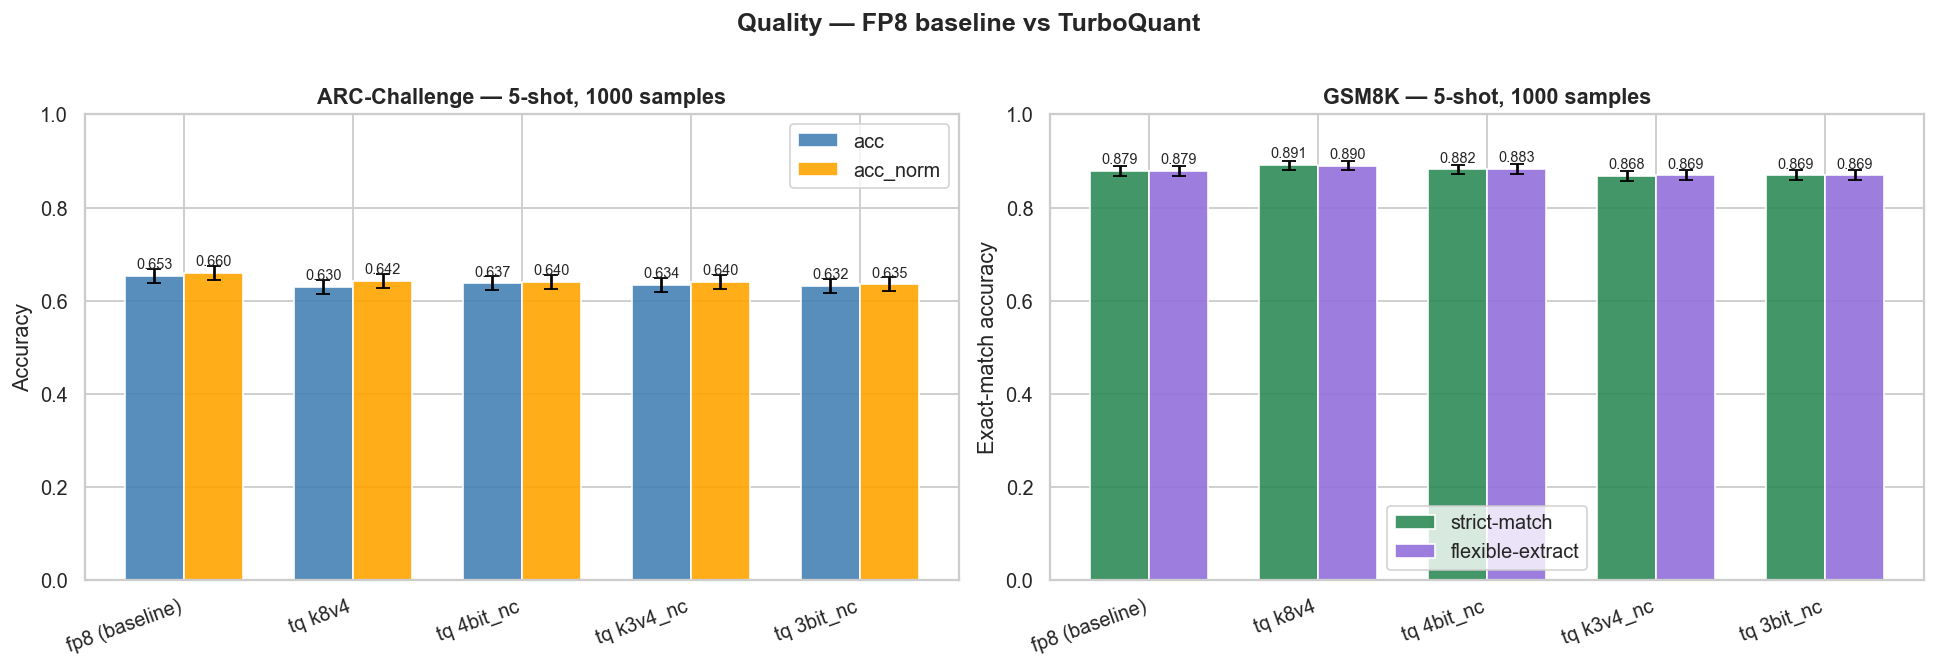

In [20]:
# ─── ARC Challenge accuracy ────────────────────────────────────────────────
arc = eval_df[eval_df['task'] == 'arc_challenge'].copy()
gsm = eval_df[eval_df['task'] == 'gsm8k'].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ARC
ax = axes[0]
x = np.arange(len(arc))
w = 0.35
ax.bar(x - w/2, arc['acc'],      width=w, yerr=arc['acc_stderr'],      capsize=4,
       label='acc',      color='steelblue', alpha=0.9)
ax.bar(x + w/2, arc['acc_norm'], width=w, yerr=arc['acc_norm_stderr'], capsize=4,
       label='acc_norm', color='orange',    alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([EXP_SHORT.get(e, e) for e in arc['experiment']], rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('ARC-Challenge — 5-shot, 1000 samples', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend()
for i, v in enumerate(arc['acc']):
    ax.annotate(f'{v:.3f}', (i - w/2, v), textcoords='offset points', xytext=(0, 4), ha='center', fontsize=8)
for i, v in enumerate(arc['acc_norm']):
    ax.annotate(f'{v:.3f}', (i + w/2, v), textcoords='offset points', xytext=(0, 4), ha='center', fontsize=8)

# GSM8K
ax = axes[1]
x = np.arange(len(gsm))
ax.bar(x - w/2, gsm['exact_match_strict'], width=w, yerr=gsm['exact_match_strict_se'], capsize=4,
       label='strict-match',     color='seagreen',  alpha=0.9)
ax.bar(x + w/2, gsm['exact_match_flex'],   width=w, yerr=gsm['exact_match_flex_se'],   capsize=4,
       label='flexible-extract', color='mediumpurple', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([EXP_SHORT.get(e, e) for e in gsm['experiment']], rotation=20, ha='right')
ax.set_ylabel('Exact-match accuracy')
ax.set_title('GSM8K — 5-shot, 1000 samples', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend()
for i, v in enumerate(gsm['exact_match_strict']):
    ax.annotate(f'{v:.3f}', (i - w/2, v), textcoords='offset points', xytext=(0, 4), ha='center', fontsize=8)
for i, v in enumerate(gsm['exact_match_flex']):
    ax.annotate(f'{v:.3f}', (i + w/2, v), textcoords='offset points', xytext=(0, 4), ha='center', fontsize=8)

plt.suptitle('Quality — FP8 baseline vs TurboQuant', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'turboquant_quality_bars.png', bbox_inches='tight')
plt.show()

In [21]:
# ─── Accuracy drop vs FP8 baseline ─────────────────────────────────────────
base_arc = arc[arc['experiment'] == BASELINE_EXP].iloc[0]
base_gsm = gsm[gsm['experiment'] == BASELINE_EXP].iloc[0]

quality_diff = []
for exp in [e for e in EXP_ORDER if e != BASELINE_EXP]:
    a = arc[arc['experiment'] == exp]
    g = gsm[gsm['experiment'] == exp]
    if a.empty or g.empty:
        continue
    a = a.iloc[0]; g = g.iloc[0]
    quality_diff.append({
        'experiment':            exp,
        'arc_acc':               a['acc'],
        'arc_acc_Δ':             a['acc'] - base_arc['acc'],
        'arc_acc_norm':          a['acc_norm'],
        'arc_acc_norm_Δ':        a['acc_norm'] - base_arc['acc_norm'],
        'gsm8k_strict':          g['exact_match_strict'],
        'gsm8k_strict_Δ':        g['exact_match_strict'] - base_gsm['exact_match_strict'],
        'gsm8k_flex':            g['exact_match_flex'],
        'gsm8k_flex_Δ':          g['exact_match_flex']   - base_gsm['exact_match_flex'],
    })

quality_diff_df = pd.DataFrame(quality_diff)
print(f'Accuracy delta vs {BASELINE_EXP} (positive = better than baseline):')
display(quality_diff_df.style.format({
    'arc_acc': '{:.3f}', 'arc_acc_norm': '{:.3f}',
    'gsm8k_strict': '{:.3f}', 'gsm8k_flex': '{:.3f}',
    'arc_acc_Δ': '{:+.3f}', 'arc_acc_norm_Δ': '{:+.3f}',
    'gsm8k_strict_Δ': '{:+.3f}', 'gsm8k_flex_Δ': '{:+.3f}',
}))

Accuracy delta vs qwen3_kv_fp8_baseline (positive = better than baseline):


,experiment,arc_acc,arc_acc_Δ,arc_acc_norm,arc_acc_norm_Δ,gsm8k_strict,gsm8k_strict_Δ,gsm8k_flex,gsm8k_flex_Δ
0,qwen3_kv_turboquant_k8v4,0.630,-0.023,0.642,-0.018,0.891,+0.012,0.890,+0.011
1,qwen3_kv_turboquant_4bit_nc,0.637,-0.016,0.640,-0.020,0.882,+0.003,0.883,+0.004
2,qwen3_kv_turboquant_k3v4_nc,0.634,-0.019,0.640,-0.020,0.868,-0.011,0.869,-0.010
3,qwen3_kv_turboquant_3bit_nc,0.632,-0.021,0.635,-0.025,0.869,-0.010,0.869,-0.010


## 10. Quality vs performance trade-off

For each KV-cache variant, plot accuracy on each task against headline performance metrics aggregated across all concurrency levels. This is the punch-line of the analysis: does aggressive KV-cache compression actually pay off?

In [22]:
# Aggregate per experiment across all concurrency levels
perf_summary = (
    df_ok.groupby('experiment')
    .agg(
        ttft_p50  = ('ttft_ms', lambda s: s.quantile(0.5)),
        ttft_p95  = ('ttft_ms', lambda s: s.quantile(0.95)),
        tpot_p50  = ('tpot_ms', lambda s: s.quantile(0.5)),
        e2e_p50   = ('e2e_ms',  lambda s: s.quantile(0.5)),
    )
    .reset_index()
)

# Throughput at the highest shared concurrency (128 users)
tput_u128 = pareto[pareto['users'] == 128][['experiment', 'token_throughput']].rename(
    columns={'token_throughput': 'throughput_u128_tok_s'}
)
perf_summary = perf_summary.merge(tput_u128, on='experiment', how='left')

# Server-side: KV-cache and VRAM at the highest concurrency
server_u128 = server_summary[server_summary['users'] == 128][
    ['experiment'] + [c for c in ['kv_cache_mean_pct', 'vram_mean_mib', 'gen_throughput_mean']
                       if c in server_summary.columns]
]
perf_summary = perf_summary.merge(server_u128, on='experiment', how='left')

# Attach quality scores
qmap = (
    arc[['experiment', 'acc', 'acc_norm']]
    .rename(columns={'acc': 'arc_acc', 'acc_norm': 'arc_acc_norm'})
    .merge(
        gsm[['experiment', 'exact_match_strict', 'exact_match_flex']]
        .rename(columns={'exact_match_strict': 'gsm8k_strict', 'exact_match_flex': 'gsm8k_flex'}),
        on='experiment', how='outer',
    )
)
perf_summary = perf_summary.merge(qmap, on='experiment', how='left')
perf_summary['experiment'] = pd.Categorical(perf_summary['experiment'], categories=EXP_ORDER, ordered=True)
perf_summary = perf_summary.sort_values('experiment').reset_index(drop=True)

print('Per-experiment performance × quality summary:')
display(perf_summary)

Per-experiment performance × quality summary:


,experiment,ttft_p50,ttft_p95,tpot_p50,e2e_p50,throughput_u128_tok_s,kv_cache_mean_pct,vram_mean_mib,gen_throughput_mean,arc_acc,arc_acc_norm,gsm8k_strict,gsm8k_flex
0,qwen3_kv_fp8_baseline,598.3,217568.7,93.8,162018.9,1096.8,0.9,20648.0,539.6,0.7,0.7,0.9,0.9
1,qwen3_kv_turboquant_k8v4,621.4,217774.2,129.7,216876.9,291.9,0.9,20228.0,266.3,0.6,0.6,0.9,0.9
2,qwen3_kv_turboquant_4bit_nc,680.5,132699.5,156.5,258918.6,575.1,0.9,20204.0,300.7,0.6,0.6,0.9,0.9
3,qwen3_kv_turboquant_k3v4_nc,753.4,49644.5,196.7,256415.5,759.9,0.9,20224.0,288.0,0.6,0.6,0.9,0.9
4,qwen3_kv_turboquant_3bit_nc,732.3,2015.1,177.8,235669.6,391.5,0.9,20254.4,270.5,0.6,0.6,0.9,0.9


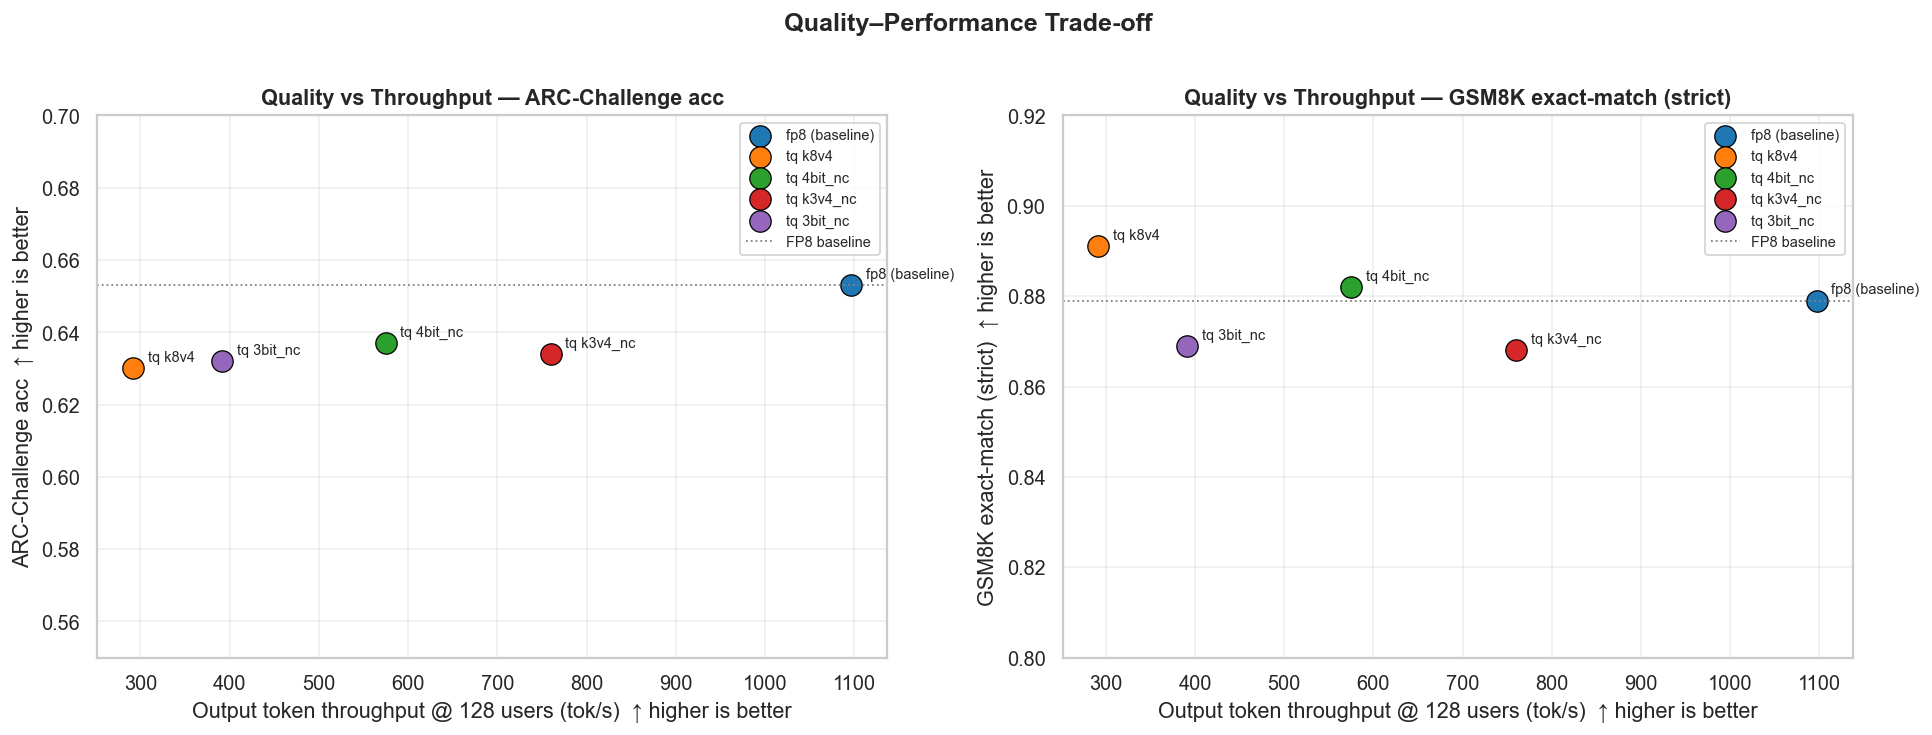

In [23]:
# ─── Quality vs Throughput scatter ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
palette = sns.color_palette('tab10', len(EXP_ORDER))
color_map = {e: c for e, c in zip(EXP_ORDER, palette)}

for ax, qmetric, qlabel, ylim in zip(
    axes,
    ['arc_acc', 'gsm8k_strict'],
    ['ARC-Challenge acc', 'GSM8K exact-match (strict)'],
    [(0.55, 0.70), (0.80, 0.92)],
):
    for _, r in perf_summary.iterrows():
        if pd.isna(r['throughput_u128_tok_s']) or pd.isna(r[qmetric]):
            continue
        c = color_map.get(r['experiment'], 'black')
        ax.scatter(r['throughput_u128_tok_s'], r[qmetric], s=140, color=c,
                   edgecolor='black', linewidth=0.7,
                   label=EXP_SHORT.get(r['experiment'], r['experiment']))
        ax.annotate(EXP_SHORT.get(r['experiment'], r['experiment']),
                    (r['throughput_u128_tok_s'], r[qmetric]),
                    textcoords='offset points', xytext=(8, 4), fontsize=8)
    # Baseline reference line
    base_q = perf_summary[perf_summary['experiment'] == BASELINE_EXP][qmetric].iloc[0]
    ax.axhline(base_q, color='gray', linestyle=':', linewidth=1, label='FP8 baseline')
    ax.set_xlabel('Output token throughput @ 128 users (tok/s)  ↑ higher is better')
    ax.set_ylabel(qlabel + '  ↑ higher is better')
    ax.set_title(f'Quality vs Throughput — {qlabel}', fontweight='bold')
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

plt.suptitle('Quality–Performance Trade-off', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'turboquant_quality_vs_throughput.png', bbox_inches='tight')
plt.show()

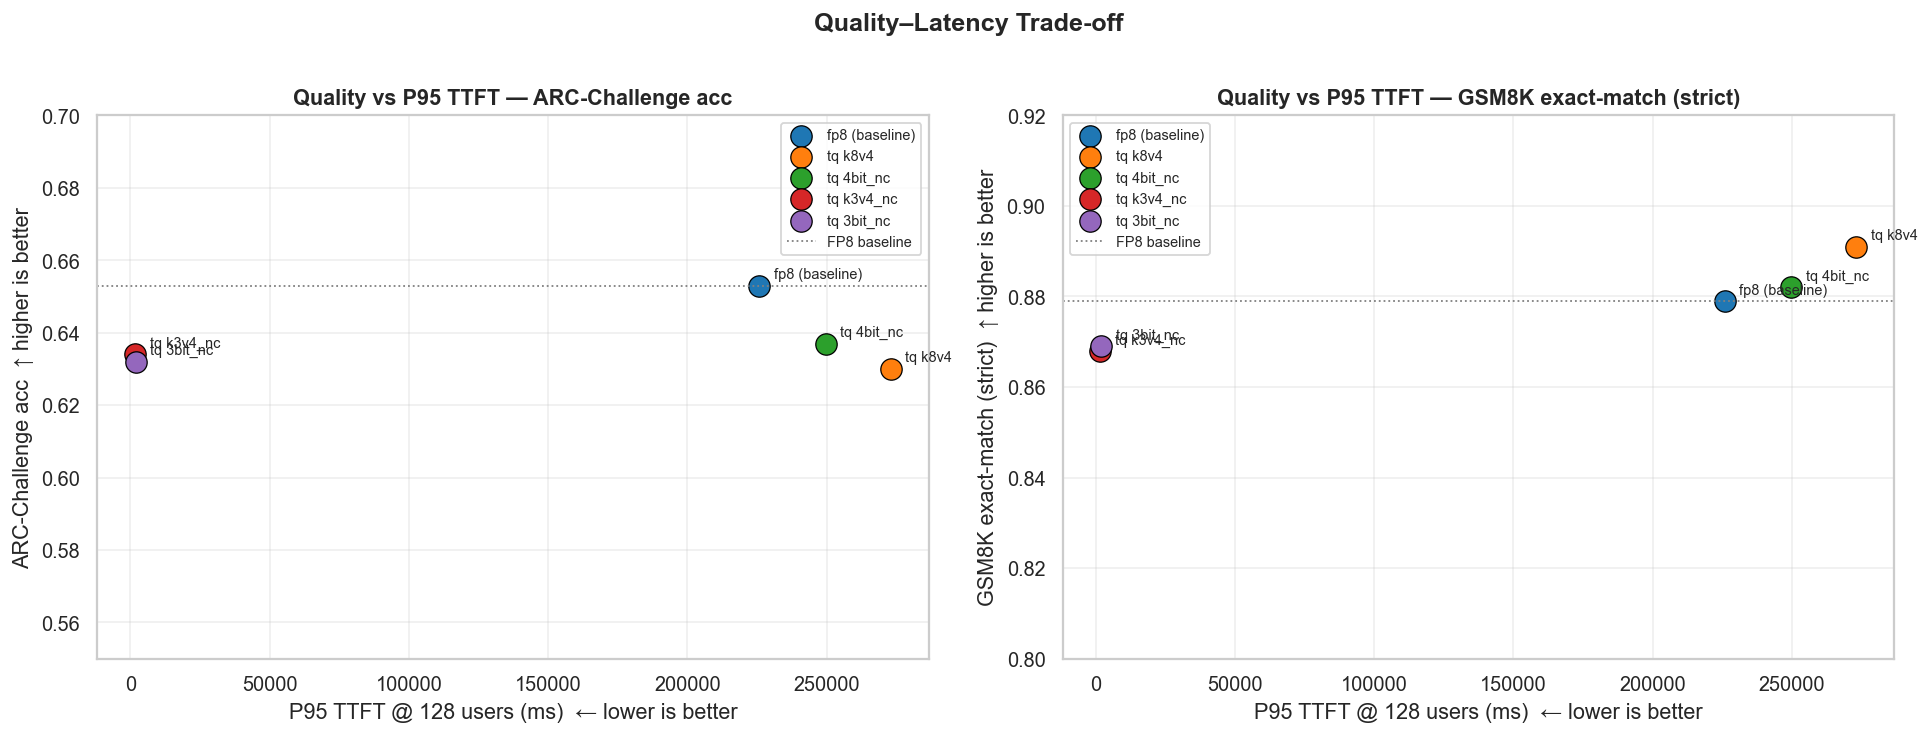

In [24]:
# ─── Quality vs P95 TTFT scatter (latency view) ────────────────────────────
tt_u128 = pareto[pareto['users'] == 128][['experiment', 'ttft_p95']]
perf_lat = perf_summary.merge(tt_u128, on='experiment', how='left', suffixes=('', '_u128'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, qmetric, qlabel, ylim in zip(
    axes,
    ['arc_acc', 'gsm8k_strict'],
    ['ARC-Challenge acc', 'GSM8K exact-match (strict)'],
    [(0.55, 0.70), (0.80, 0.92)],
):
    for _, r in perf_lat.iterrows():
        if pd.isna(r['ttft_p95_u128']) or pd.isna(r[qmetric]):
            continue
        c = color_map.get(r['experiment'], 'black')
        ax.scatter(r['ttft_p95_u128'], r[qmetric], s=140, color=c,
                   edgecolor='black', linewidth=0.7,
                   label=EXP_SHORT.get(r['experiment'], r['experiment']))
        ax.annotate(EXP_SHORT.get(r['experiment'], r['experiment']),
                    (r['ttft_p95_u128'], r[qmetric]),
                    textcoords='offset points', xytext=(8, 4), fontsize=8)
    base_q = perf_summary[perf_summary['experiment'] == BASELINE_EXP][qmetric].iloc[0]
    ax.axhline(base_q, color='gray', linestyle=':', linewidth=1, label='FP8 baseline')
    ax.set_xlabel('P95 TTFT @ 128 users (ms)  ← lower is better')
    ax.set_ylabel(qlabel + '  ↑ higher is better')
    ax.set_title(f'Quality vs P95 TTFT — {qlabel}', fontweight='bold')
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

plt.suptitle('Quality–Latency Trade-off', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'turboquant_quality_vs_ttft.png', bbox_inches='tight')
plt.show()

## 11. Error analysis

In [25]:
errors = df_all[(df_all['success'] == False) & (df_all['experiment'].isin(EXP_ORDER))]
print(f'Total failed requests: {len(errors)}')
if not errors.empty:
    display(errors.groupby(['run', 'experiment', 'users', 'error_type']).size()
                  .rename('count').reset_index())
else:
    print('✅ No errors across any experiment.')

Total failed requests: 113


,run,experiment,users,error_type,count
0,run1,qwen3_kv_turboquant_4bit_nc,128,ConnectionError,28
1,run1,qwen3_kv_turboquant_k8v4,128,ConnectionError,21
2,run2,qwen3_kv_turboquant_3bit_nc,128,ConnectionError,32
3,run2,qwen3_kv_turboquant_k3v4_nc,128,ConnectionError,32


## 12. Export unified summary

In [26]:
unified = summary_agg.merge(
    server_summary,
    on=['experiment', 'users'],
    how='left',
)
unified['experiment'] = pd.Categorical(unified['experiment'], categories=EXP_ORDER, ordered=True)
unified = unified.sort_values(['experiment', 'users']).reset_index(drop=True)

out_path = RESULTS_ROOT / 'unified_summary_turboquant.csv'
unified.to_csv(out_path, index=False)
print(f'✅ Unified summary saved to: {out_path}')

perf_summary.to_csv(RESULTS_ROOT / 'turboquant_perf_quality_summary.csv', index=False)
print(f'✅ Per-experiment perf×quality summary saved to: {RESULTS_ROOT / "turboquant_perf_quality_summary.csv"}')

display(unified)

✅ Unified summary saved to: results/unified_summary_turboquant.csv
✅ Per-experiment perf×quality summary saved to: results/turboquant_perf_quality_summary.csv


,experiment,users,n,ttft_mean,ttft_p50,ttft_p95,ttft_p99,tpot_mean,tpot_p50,tpot_p99,e2e_mean,e2e_p50,e2e_p99,itl_p50_mean,itl_p99_mean,output_tokens,gpu_util_mean,gpu_util_max,vram_mean_mib,vram_max_mib,kv_cache_mean_pct,kv_cache_max_pct,requests_running_mean,requests_waiting_mean,requests_waiting_max,gen_throughput_mean
0,qwen3_kv_fp8_baseline,32,76,1033.3,445.6,5901.5,10763.9,63.6,64.1,79.9,121423.7,101658.0,424944.4,60.0,160.8,147636,98.2,100.0,20631.7,20648.0,0.3,0.6,17.5,0.0,0.0,288.3
1,qwen3_kv_fp8_baseline,64,125,876.0,499.1,1639.2,11503.9,87.5,89.2,100.8,145536.4,137107.5,355666.6,81.1,371.3,208868,97.3,100.0,20648.0,20648.0,0.6,1.0,36.8,0.3,5.0,435.4
2,qwen3_kv_fp8_baseline,128,162,68028.8,1019.9,225835.1,239384.9,118.7,107.3,266.7,243603.3,244929.4,467792.5,91.6,472.6,243524,100.0,100.0,20648.0,20648.0,0.9,1.0,57.4,38.5,73.0,539.6
3,qwen3_kv_turboquant_k8v4,32,53,1491.7,542.3,8452.3,12253.9,94.3,95.9,107.6,173423.8,163928.2,379325.3,91.1,232.1,96893,97.2,100.0,20225.4,20228.0,0.5,0.9,18.5,0.0,0.0,203.7
4,qwen3_kv_turboquant_k8v4,64,72,27441.6,554.4,169227.9,192319.5,152.7,131.3,403.8,257614.5,254701.3,489433.7,120.4,488.5,112292,97.3,100.0,20228.0,20228.0,0.9,1.0,33.6,11.3,35.0,263.1
5,qwen3_kv_turboquant_k8v4,128,40,63276.4,929.9,272999.3,293132.9,175.1,137.7,514.8,256157.5,246515.4,488823.5,126.8,573.6,48470,91.1,100.0,20228.0,20228.0,0.9,1.0,36.4,54.6,96.0,266.3
6,qwen3_kv_turboquant_4bit_nc,32,51,1683.3,649.3,9463.5,13111.1,99.7,101.4,114.5,174252.3,160623.8,351366.5,97.6,244.7,89093,97.2,100.0,20204.0,20204.0,0.4,0.7,17.6,0.0,0.0,186.0
7,qwen3_kv_turboquant_4bit_nc,64,80,15050.3,610.7,110159.8,136858.4,151.4,150.1,237.7,254342.6,255297.1,492628.0,144.3,517.1,125470,97.1,100.0,20204.0,20204.0,0.8,1.0,40.4,4.8,24.0,270.9
8,qwen3_kv_turboquant_4bit_nc,128,86,27968.1,810.5,249682.6,299838.4,224.4,170.1,1106.6,299861.8,304974.2,504386.8,157.4,652.4,119278,91.2,100.0,20204.0,20204.0,0.9,1.0,51.9,39.4,80.0,300.7
9,qwen3_kv_turboquant_k3v4_nc,64,67,8913.8,770.6,58352.1,75511.0,177.4,175.8,236.9,240840.6,229213.2,489829.1,172.1,611.9,87434,94.5,100.0,20224.0,20224.0,0.8,1.0,44.0,2.2,11.0,253.8
